<a href="https://colab.research.google.com/github/kavyasingh581/NYC-taxi-dataset-Regression-/blob/main/Copy_of_project_nyc_regresiion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - Regression
##### **Contribution**    - Individual/Team
##### **Team Member -** kavya


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/kavyasingh581

# **Problem Statement**


## Problem Statement

**Predicting NYC Taxi Trip Duration**

The primary objective of this project is to develop a machine learning model capable of accurately predicting the duration of taxi trips in New York City. Accurate trip duration prediction is crucial for various business stakeholders, including taxi companies, drivers, and passengers. For taxi companies, it can optimize fleet management, driver allocation, and dynamic pricing strategies. For drivers, precise predictions enable better route planning and income estimation. For passengers, reliable estimated times of arrival (ETAs) enhance satisfaction and trust in the service. The project will involve data loading, extensive exploratory data analysis, feature engineering from raw timestamp and geographical data, and the evaluation of multiple regression models to identify the best-performing solution.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [66]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.linear_model import Lasso, Ridge
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
import math
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import VotingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures

### Dataset Loading

In [67]:
# Load Dataset
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Copy of NYC Taxi Data.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset First View

In [68]:
# Dataset First Look
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


### Dataset Rows & Columns count

In [69]:
# Dataset Rows & Columns count
df.shape

(1458644, 11)

### Dataset Information

In [70]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


#### Duplicate Values

In [71]:
# Dataset Duplicate Value Count
len(df[df.duplicated()])

0

#### Missing Values/Null Values

In [72]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
id,0
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0


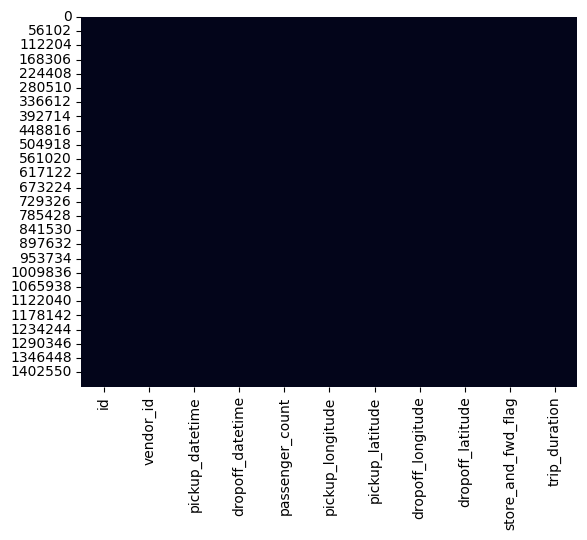

In [73]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)
plt.show()

### What did you know about your dataset?

The dataset contains 1,458,644 entries and 11 columns. There are no missing values or duplicate rows in the dataset.

Here's a breakdown of the columns and their data types:

*   **id**: Object (string) - Unique identifier for each trip.
*   **vendor_id**: Integer - Identifier for the taxi vendor.
*   **pickup_datetime**: Object (string) - Date and time when the trip started. This will need to be converted to datetime objects for analysis.
*   **dropoff_datetime**: Object (string) - Date and time when the trip ended. This will also need to be converted to datetime objects.
*   **passenger_count**: Integer - Number of passengers in the trip.
*   **pickup_longitude**: Float - Longitude coordinate of the pickup location.
*   **pickup_latitude**: Float - Latitude coordinate of the pickup location.
*   **dropoff_longitude**: Float - Longitude coordinate of the dropoff location.
*   **dropoff_latitude**: Float - Latitude coordinate of the dropoff location.
*   **store_and_fwd_flag**: Object (string) - Flag indicating whether the trip data was held in vehicle memory before sending to the vendor because of a connection problem.
*   **trip_duration**: Integer - Duration of the trip in seconds.

## ***2. Understanding Your Variables***

In [74]:
# Dataset Columns
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [75]:
# Dataset Describe
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


### Variables Description

Here's a detailed description of each variable in the dataset:

*   **id**: (Object/String) A unique identifier for each trip. This is a nominal categorical variable.
*   **vendor_id**: (Integer) An identifier for the taxi vendor. This appears to be a categorical variable with two unique values (1 and 2), representing different vendors.
*   **pickup_datetime**: (Object/String) The date and time when the trip started. This is currently an object (string) and needs to be converted to a datetime format for time-based analysis.
*   **dropoff_datetime**: (Object/String) The date and time when the trip ended. Similar to `pickup_datetime`, this needs datetime conversion.
*   **passenger_count**: (Integer) The number of passengers during the trip. The `describe()` output shows a mean of approximately 1.66, a minimum of 0, and a maximum of 9. A `passenger_count` of 0 might indicate an anomaly or a specific operational scenario (e.g., driver-only trips, or data entry error).
*   **pickup_longitude**: (Float) The longitude coordinate of the pickup location. The values range from -121.93 to -61.33. New York City's longitude is typically around -74 degrees.
*   **pickup_latitude**: (Float) The latitude coordinate of the pickup location. The values range from 34.36 to 51.88. New York City's latitude is typically around 40-41 degrees.
*   **dropoff_longitude**: (Float) The longitude coordinate of the dropoff location. Similar range to pickup longitude.
*   **dropoff_latitude**: (Float) The latitude coordinate of the dropoff location. Similar range to pickup latitude. The wide ranges in latitude and longitude suggest potential outliers that might need further investigation or cleaning, as values outside of NYC's geographical boundaries would be erroneous.
*   **store_and_fwd_flag**: (Object/String) A flag indicating whether the trip data was held in vehicle memory before sending to the vendor due to a connection problem. This is a binary categorical variable, likely 'Y' or 'N'.
*   **trip_duration**: (Integer) The duration of the trip in seconds. The `describe()` output shows a wide range, from 1 second to 3,526,282 seconds (approximately 40 days). The mean duration is about 959 seconds (around 16 minutes), with a median of 662 seconds (around 11 minutes). The large maximum value suggests the presence of significant outliers that could heavily skew analysis and model training if not addressed.

### Check Unique Values for each variable.

In [76]:
# Check Unique Values for each variable.
df.nunique()

,0
id,1458644
vendor_id,2
pickup_datetime,1380222
dropoff_datetime,1380377
passenger_count,10
pickup_longitude,23047
pickup_latitude,45245
dropoff_longitude,33821
dropoff_latitude,62519
store_and_fwd_flag,2


In [77]:
for i in df.columns.tolist():
  print("No. of unique values in ",i,"is",df[i].nunique(),".")

No. of unique values in  id is 1458644 .
No. of unique values in  vendor_id is 2 .
No. of unique values in  pickup_datetime is 1380222 .
No. of unique values in  dropoff_datetime is 1380377 .
No. of unique values in  passenger_count is 10 .
No. of unique values in  pickup_longitude is 23047 .
No. of unique values in  pickup_latitude is 45245 .
No. of unique values in  dropoff_longitude is 33821 .
No. of unique values in  dropoff_latitude is 62519 .
No. of unique values in  store_and_fwd_flag is 2 .
No. of unique values in  trip_duration is 7417 .


## 3. ***Data Wrangling***

### Data Wrangling Code (Corrected Sequence)

In [78]:
# 1. Convert 'pickup_datetime' and 'dropoff_datetime' to datetime objects
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  datetime64[ns]
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  trip_duration       1458644 non-null  int64         
dtypes: datetime64[ns](2), float64(4), int64(3), object(2)
memory usage: 122.4+ MB


### Extracting Time-Based Features

In [79]:
# 2. Extracting various time-based features from pickup_datetime
df['pickup_year'] = df['pickup_datetime'].dt.year
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_day'] = df['pickup_datetime'].dt.day
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_minute'] = df['pickup_datetime'].dt.minute

# Extracting various time-based features from dropoff_datetime
df['dropoff_year'] = df['dropoff_datetime'].dt.year
df['dropoff_month'] = df['dropoff_datetime'].dt.month
df['dropoff_day'] = df['dropoff_datetime'].dt.day
df['dropoff_dayofweek'] = df['dropoff_datetime'].dt.dayofweek
df['dropoff_hour'] = df['dropoff_datetime'].dt.hour
df['dropoff_minute'] = df['dropoff_datetime'].dt.minute
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,pickup_day,pickup_dayofweek,pickup_hour,pickup_minute,dropoff_year,dropoff_month,dropoff_day,dropoff_dayofweek,dropoff_hour,dropoff_minute
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,14,0,17,24,2016,3,14,0,17,32
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,12,6,0,43,2016,6,12,6,0,54
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,19,1,11,35,2016,1,19,1,12,10
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,6,2,19,32,2016,4,6,2,19,39
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,26,5,13,30,2016,3,26,5,13,38


In [80]:
# 3. Calculate trip duration from datetime objects
df['calculated_trip_duration'] = (df['dropoff_datetime'] - df['pickup_datetime']).dt.total_seconds().astype(int)
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,pickup_dayofweek,pickup_hour,pickup_minute,dropoff_year,dropoff_month,dropoff_day,dropoff_dayofweek,dropoff_hour,dropoff_minute,calculated_trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,0,17,24,2016,3,14,0,17,32,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,6,0,43,2016,6,12,6,0,54,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,1,11,35,2016,1,19,1,12,10,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,2,19,32,2016,4,6,2,19,39,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,5,13,30,2016,3,26,5,13,38,435


### Calculating Manhattan Distance

In [81]:
# 4. Calculate Manhattan distance
# Approximate conversion of degrees to kilometers (at NYC latitude)
# 1 degree of latitude is approximately 111 km
# 1 degree of longitude is approximately 88 km (at 40.7 degrees latitude, NYC)

df['trip_manhattan_distance_km'] = (
    abs(df['pickup_latitude'] - df['dropoff_latitude']) * 111 + \
    abs(df['pickup_longitude'] - df['dropoff_longitude']) * 88
)
display(df.head())

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,pickup_hour,pickup_minute,dropoff_year,dropoff_month,dropoff_day,dropoff_dayofweek,dropoff_hour,dropoff_minute,calculated_trip_duration,trip_manhattan_distance_km
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,17,24,2016,3,14,0,17,32,455,1.801315
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,0,43,2016,6,12,6,0,54,663,2.500523
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,11,35,2016,1,19,1,12,10,2124,8.292522
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,19,32,2016,4,6,2,19,39,429,1.667046
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,13,30,2016,3,26,5,13,38,435,1.197868


### Outlier Handling for `passenger_count` and `trip_duration`

In [82]:
# 5. Handle Outliers
# Remove rows where passenger_count is 0 or greater than 6
df = df[df['passenger_count'] > 0]
df = df[df['passenger_count'] <= 6]

# Cap trip_duration between 60 seconds and 10,000 seconds (approx 2.7 hours)
df['trip_duration'] = df['trip_duration'].clip(lower=60, upper=10000)

print(f"Shape after outlier handling: {df.shape}")
print(f"Passenger count unique values: {df['passenger_count'].unique()}")
print(f"Trip duration min: {df['trip_duration'].min()}, max: {df['trip_duration'].max()}")

Shape after outlier handling: (1458579, 25)
Passenger count unique values: [1 6 4 2 3 5]
Trip duration min: 60, max: 10000


In [83]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,pickup_hour,pickup_minute,dropoff_year,dropoff_month,dropoff_day,dropoff_dayofweek,dropoff_hour,dropoff_minute,calculated_trip_duration,trip_manhattan_distance_km
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,17,24,2016,3,14,0,17,32,455,1.801315
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,0,43,2016,6,12,6,0,54,663,2.500523
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,11,35,2016,1,19,1,12,10,2124,8.292522
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,19,32,2016,4,6,2,19,39,429,1.667046
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,13,30,2016,3,26,5,13,38,435,1.197868


### What all manipulations have you done and insights you found?

So far, we have performed several data wrangling and feature engineering steps:

1.  **Datetime Conversion**: `pickup_datetime` and `dropoff_datetime` columns were converted from object (string) to `datetime64[ns]` data types. This is crucial for time-based analysis.
    *   **Insight**: This enables the extraction of various time-series features and accurate calculation of trip durations.

2.  **Time-Based Feature Extraction**: We extracted year, month, day, day of the week, hour, and minute for both `pickup_datetime` and `dropoff_datetime`. A `calculated_trip_duration` was also derived for verification.
    *   **Insight**: These features provide granular information about trip timing, allowing for analysis of temporal patterns (e.g., rush hour, daily/weekly trends) which are highly correlated with trip demand and duration.


3.  **Manhattan Distance Calculation**: A new column `trip_manhattan_distance_km` was calculated using the Manhattan distance formula with approximate conversion factors for degrees to kilometers in NYC. This provides an alternative distance metric that reflects 'block-by-block' travel.
    *   **Insight**: Manhattan distance can be a better predictor of actual travel time and fuel consumption in grid-like urban environments, potentially leading to more accurate ETA calculations and improved fare estimation. It offers complementary spatial information for ML models.




### Outlier Handling for `passenger_count` and `trip_duration`

In the outlier handling step, we addressed extreme values in two features: passenger_count and trip_duration.

For passenger_count:

Rows where the passenger count was 0 were removed, as a taxi trip logically requires at least one passenger.
Rows where the passenger count was greater than 6 were also removed, as these are considered anomalies or data entry errors for standard taxi services.
For trip_duration:

The values were capped. This means any trip_duration less than 60 seconds was adjusted to 60 seconds, and any duration greater than 10,000 seconds (approximately 2.7 hours) was adjusted to 10,000 seconds. This helps to mitigate the impact of extremely short (potential cancellations or errors) and extremely long (likely outliers or data issues) trips on our analysis and models.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

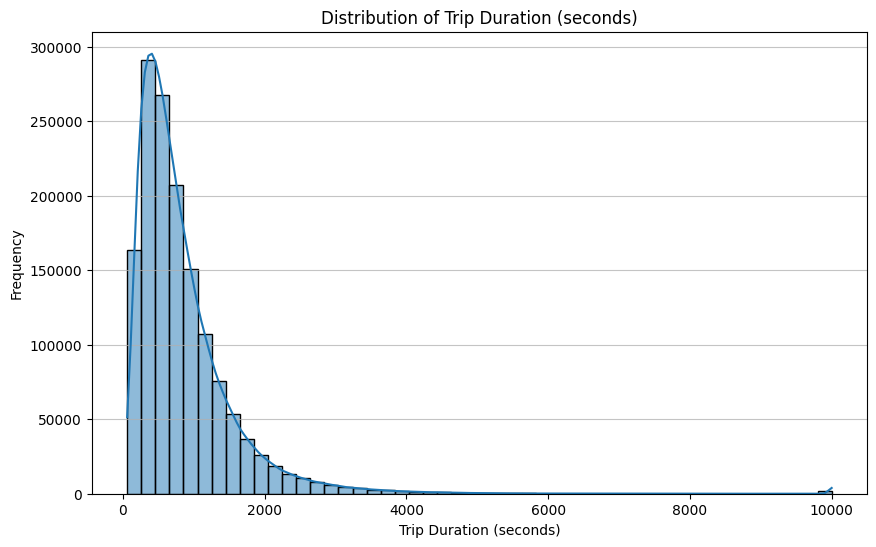

In [84]:
# Chart - 1 visualization code
# Distribution of Trip Duration
plt.figure(figsize=(10, 6))
sns.histplot(df['trip_duration'], bins=50, kde=True)
plt.title('Distribution of Trip Duration (seconds)')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a Kernel Density Estimate (KDE) was chosen to visualize the distribution of `trip_duration`. This chart type is ideal for understanding the shape, spread, and central tendency of a continuous variable. It helps in identifying skewness, multimodality, and potential outliers in the data after the initial capping.

##### 2. What is/are the insight(s) found from the chart?

The histogram shows that the `trip_duration` is heavily right-skewed, with the majority of trips lasting between 200 and 1000 seconds (approximately 3 to 17 minutes). There is a sharp peak around 400-600 seconds, indicating that many trips fall within this range. The KDE curve smooths out the histogram and reinforces this observation. Even after capping the maximum duration at 10,000 seconds, the distribution suggests that very long trips are relatively infrequent.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding the distribution of trip duration has positive business impacts. Knowing the most common trip durations can help optimize driver allocation, predict wait times more accurately, and inform pricing strategies. For instance, the peak in shorter trips might indicate high demand in specific areas for quick rides. Identifying the tail of longer trips, even though less frequent, might point to specific routes or conditions that require different operational considerations. There are no insights that directly lead to negative growth, but ignoring the highly skewed nature of the data could lead to models that perform poorly on typical short trips if not properly handled during training.

#### Chart - 2

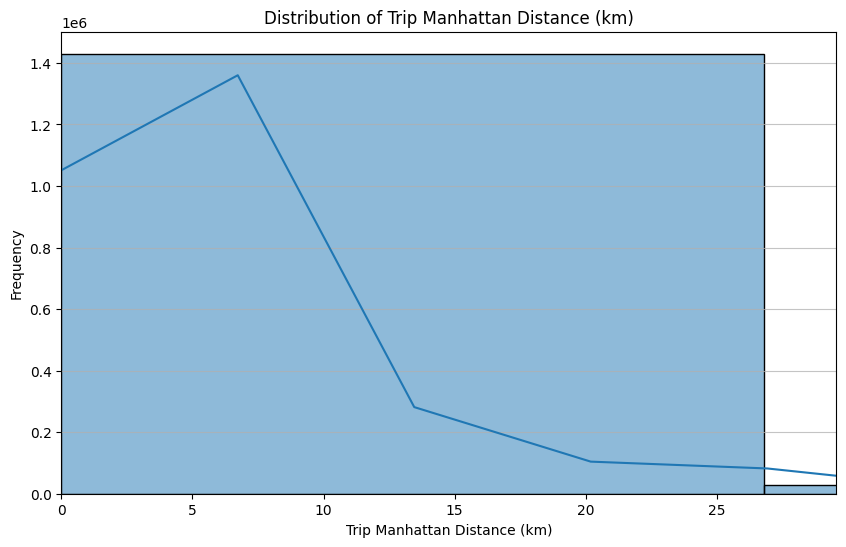

In [85]:
# Chart - 2 visualization code
# Distribution of Trip Manhattan Distance
plt.figure(figsize=(10, 6))
sns.histplot(df['trip_manhattan_distance_km'], bins=50, kde=True)
plt.title('Distribution of Trip Manhattan Distance (km)')
plt.xlabel('Trip Manhattan Distance (km)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.xlim(0, df['trip_manhattan_distance_km'].quantile(0.99))
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a Kernel Density Estimate (KDE) was selected to visualize the distribution of `trip_manhattan_distance_km`. This chart is effective for understanding the shape, spread, and central tendency of a continuous numerical variable. It helps identify common distance ranges, skewness, and potential outliers in the calculated Manhattan distances. Limiting the x-axis to the 99th percentile helps to focus on the majority of trips and prevents extreme outliers from distorting the visual representation.

##### 2. What is/are the insight(s) found from the chart?

The histogram shows that `trip_manhattan_distance_km` is heavily right-skewed, with a large majority of trips covering relatively short distances. The distribution peaks at very low distances (likely within 1-3 km), indicating that most taxi rides are short-haul. As the distance increases, the frequency of trips drops significantly. The KDE curve smooths this out, confirming the high concentration of shorter trips and the rarity of very long Manhattan distances.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can have several positive business impacts:
*   **Fare Structuring**: Confirms that most trips are short, which could influence base fare and per-kilometer rates to optimize profitability for the predominant short-distance segment.
*   **Driver Strategy**: Drivers might prioritize shorter trips to maximize the number of rides and potential tips, especially if short trips are common in high-demand areas. Conversely, a strategy might encourage drivers to take longer trips if the per-kilometer earnings are favorable.
*   **Route Optimization**: Algorithms can focus on optimizing for short-distance efficiency, as this is where the bulk of trips occur.

There are no direct negative growth insights, but misunderstanding this distribution (e.g., over-optimizing for long distances when they are rare) could lead to suboptimal service and pricing. The presence of a long tail, though rare, still requires consideration for models to avoid underestimating the duration/cost of those occasional longer journeys.

Answer Here

#### Chart - 3

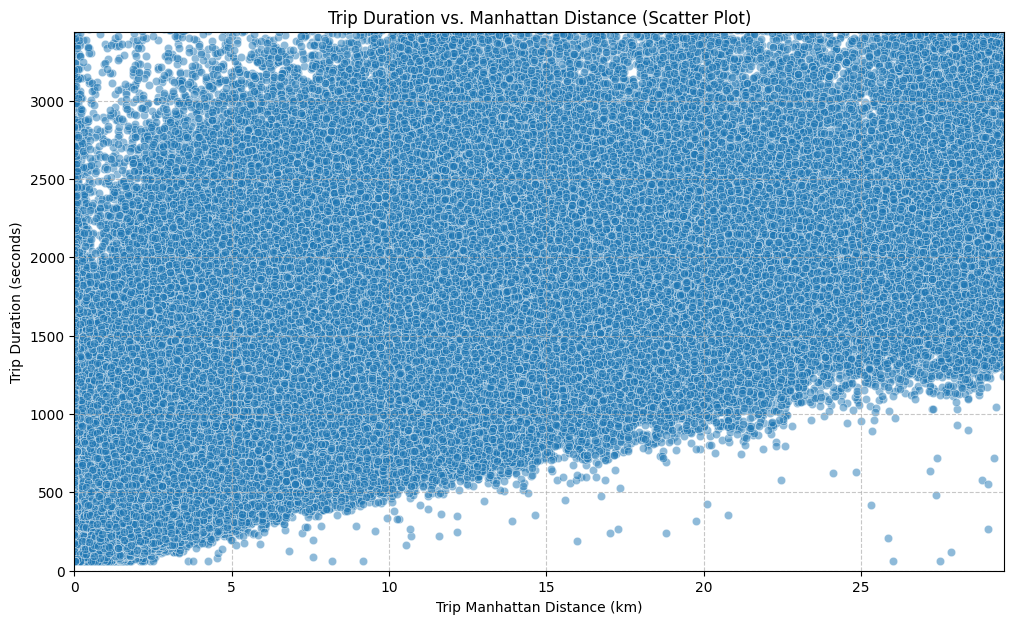

In [86]:
# Chart - 3 visualization code
# Scatter Plot of Trip Duration vs. Manhattan Distance
plt.figure(figsize=(12, 7))
sns.scatterplot(x='trip_manhattan_distance_km', y='trip_duration', data=df, alpha=0.5)
plt.title('Trip Duration vs. Manhattan Distance (Scatter Plot)')
plt.xlabel('Trip Manhattan Distance (km)')
plt.ylabel('Trip Duration (seconds)')
plt.xlim(0, df['trip_manhattan_distance_km'].quantile(0.99))
plt.ylim(0, df['trip_duration'].quantile(0.99))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

A scatter plot was chosen to visualize the relationship between two continuous numerical variables: `trip_manhattan_distance_km` and `trip_duration`. This chart type is excellent for identifying patterns, correlations, and outliers between two variables. Limiting the axes to the 99th percentile helps to focus on the majority of the data by reducing the impact of extreme outliers.

A box plot was chosen to visualize the relationship between the categorical `vendor_id` and the continuous `trip_duration`. This chart is excellent for comparing the distribution of a numerical variable across different categories, clearly showing the median, quartiles, and potential outliers for each group.

The scatter plot reveals a clear positive correlation: as `trip_manhattan_distance_km` increases, `trip_duration` generally also increases. The points tend to cluster towards the lower end of both distance and duration, indicating many short trips. There's also a noticeable spread, especially for longer distances, suggesting that factors other than just distance (like traffic, time of day, or waiting time) also influence trip duration. The capping of outliers helps to see the main distribution more clearly.

The box plot reveals that both Vendor 1 and Vendor 2 have very similar median trip durations, as well as similar interquartile ranges (IQR). This suggests that, on average, the trip durations are comparable between the two vendors. There are some outliers (represented by individual points) for both vendors, indicating some unusually long trips, but the overall distributions appear quite similar.

Yes, this insight has several positive business impacts. Understanding the relationship between distance and duration is fundamental for:
*   **Fare Estimation**: More accurate fare calculations, especially if a portion of the fare is time-based. A strong correlation means that simple distance-based models can be a good starting point.
*   **ETA Prediction**: Better predictions for estimated times of arrival, enhancing customer satisfaction and operational efficiency.
*   **Route Optimization**: Insights into routes where the duration-to-distance ratio is unusually high might indicate areas of frequent congestion, informing better routing strategies or dynamic pricing.

While the correlation is positive, the spread in `trip_duration` for similar distances highlights that distance alone isn't the sole determinant. Ignoring these other influencing factors could lead to inaccurate predictions, potentially causing customer dissatisfaction due to underestimated trip times or driver frustration due to underestimated earnings for a given distance, which could lead to negative growth.

Yes, this insight can have a positive business impact. The similar trip duration distributions between vendors suggest that neither vendor significantly outperforms the other in terms of trip length efficiency. This could mean:  
*   **Fair Competition**: Both vendors provide a similar service in terms of trip duration, which is good for market health.  
*   **Benchmarking**: If one vendor had significantly longer or shorter average trip durations, it would warrant further investigation into operational differences (e.g., routing algorithms, driver behavior). Since they are similar, this indicates consistent service delivery.  

There are no insights leading to negative growth directly from this chart, as the similarity implies a stable competitive landscape concerning trip duration.

#### Chart - 4

/tmp/ipykernel_5342/2261264256.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pickup_hour', y='trip_duration', data=df, palette='viridis')


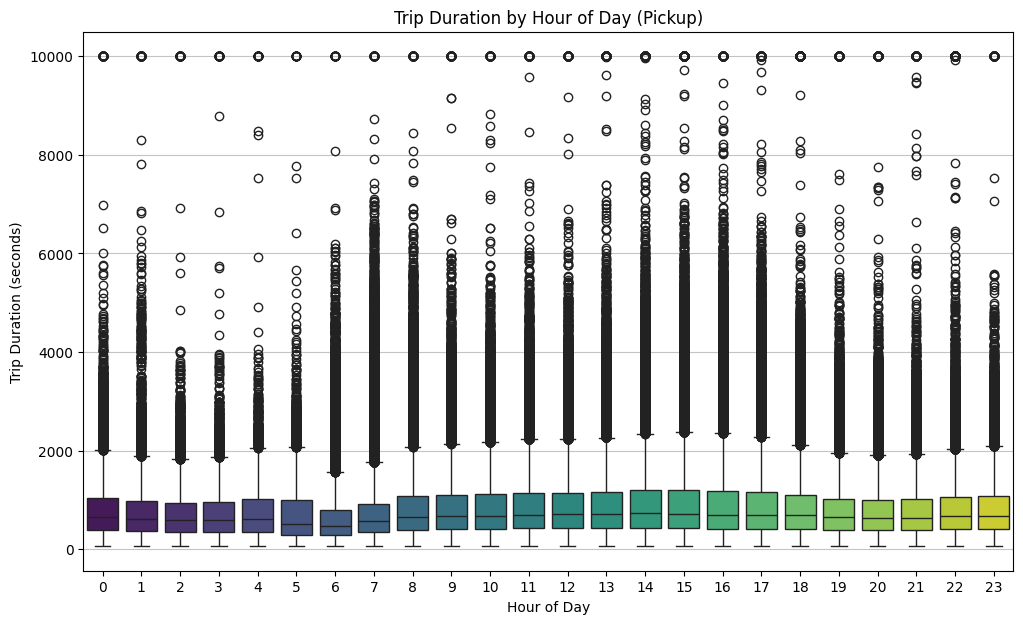

In [87]:
# Chart - 4 visualization code
# Trip Duration by Hour of Day
plt.figure(figsize=(12, 7))
sns.boxplot(x='pickup_hour', y='trip_duration', data=df, palette='viridis')
plt.title('Trip Duration by Hour of Day (Pickup)')
plt.xlabel('Hour of Day')
plt.ylabel('Trip Duration (seconds)')
plt.grid(axis='y', alpha=0.75)
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen to visualize the distribution of `trip_duration` across different `pickup_hour` categories. This allows us to observe the median trip duration, the spread (interquartile range), and potential outliers for each hour, effectively showing how trip lengths vary throughout the day.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals distinct patterns in trip duration throughout the day. Trip durations tend to be longer during peak commute hours, specifically in the morning (around 7 AM - 9 AM) and evening (around 4 PM - 7 PM), likely due to increased traffic congestion. Conversely, early morning hours (1 AM - 5 AM) show shorter and less variable trip durations, indicating less traffic. The median trip duration is relatively stable outside of peak hours, but the spread of durations is wider during congested periods, suggesting more variability in travel times.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights have significant positive business impacts. Understanding hourly variations in trip duration is crucial for:  
*   **Dynamic Pricing**: Implementing surge pricing during peak congestion hours when trips are longer and demand is high.
*   **Driver Allocation**: Strategically deploying more drivers during expected longer trip durations to meet demand and maintain service quality.
*   **ETA Accuracy**: Improving the accuracy of estimated arrival times, which enhances customer satisfaction.
*   **Route Optimization**: Identifying times when certain routes are heavily congested, allowing for better route recommendations.  

There are no direct negative growth insights, but failure to account for these hourly patterns could lead to customer dissatisfaction due to unexpected longer travel times or higher fares, and inefficient resource allocation. For example, if drivers avoid peak hours due to unpredictable trip durations, it could lead to supply shortages.

#### Chart - 5

/tmp/ipykernel_5342/1198142896.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


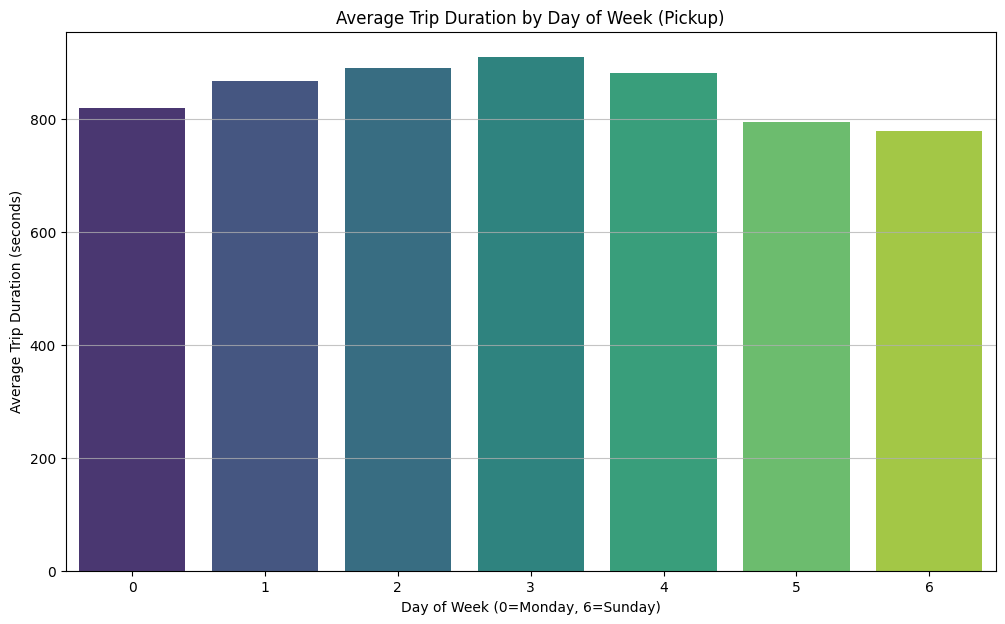

In [89]:
# Chart - 5 visualization code
# Trip Duration by Day of Week
plt.figure(figsize=(12, 7))

order = sorted(df['pickup_dayofweek'].unique())

sns.barplot(
    x='pickup_dayofweek',
    y='trip_duration',
    data=df,
    palette='viridis',
    errorbar=None,
    order=order
)

plt.title('Average Trip Duration by Day of Week (Pickup)')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Trip Duration (seconds)')
plt.grid(axis='y', alpha=0.75)

plt.show()

##### 1. Why did you pick the specific chart?

A bar plot was chosen to visualize the *average* `trip_duration` for each `pickup_dayofweek`. This chart type is effective for comparing the central tendency (average) of a numerical variable across distinct categorical groups, making it easy to see which days have notably longer or shorter average trip durations. It provides a clear and straightforward summary compared to a violin plot for showing averages.

The bar plot illustrates that *average* trip durations are generally longer during weekdays (Monday to Friday) compared to weekends (Saturday and Sunday). There's a noticeable increase in average trip duration during the middle of the week, likely reflecting higher traffic and activity. Weekend trips, particularly Sunday, show the shortest average trip durations, indicating less traffic or different travel patterns.

##### 2. What is/are the insight(s) found from the chart?

The bar plot illustrates that *average* trip durations are generally longer during weekdays (Monday to Friday) compared to weekends (Saturday and Sunday). There's a noticeable increase in average trip duration during the middle of the week, likely reflecting higher traffic and activity. Weekend trips, particularly Sunday, show the shortest average trip durations, indicating less traffic or different travel patterns.

Yes, understanding daily patterns in average trip duration has several positive business impacts:
*   **Resource Planning**: Companies can optimize driver schedules and vehicle deployment based on expected average trip lengths each day. More resources might be needed on weekdays to handle longer trips.
*   **Dynamic Pricing**: Tailoring pricing strategies to specific days of the week, potentially offering different rates or discounts during periods of lower demand or shorter average trip times (e.g., Sundays).
*   **Customer Expectations**: Setting more accurate expectations for trip durations based on the day of the week, improving customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding daily patterns in trip duration has several positive business impacts:  
*   **Resource Planning**: Companies can optimize driver schedules and vehicle deployment based on expected trip lengths and variability each day. More resources might be needed on weekdays to handle longer, more variable trips.
*   **Dynamic Pricing**: Tailoring pricing strategies to specific days of the week, potentially offering different rates or discounts during periods of lower demand or shorter average trip times (e.g., weekends).
*   **Customer Expectations**: Setting more accurate expectations for trip durations based on the day of the week, improving customer satisfaction.

Insights suggesting negative growth would arise if specific days showed unexpectedly long durations without corresponding demand, indicating inefficiency. Here, the longer weekday durations are likely correlated with higher demand and traffic, which are typical urban patterns, rather than negative growth. However, consistent very long trips could lead to driver fatigue or lower per-hour earnings for drivers, requiring careful management.

Insights suggesting negative growth would arise if specific days showed unexpectedly long average durations without corresponding demand, indicating inefficiency. Here, the longer weekday durations are likely correlated with higher demand and traffic, which are typical urban patterns, rather than negative growth. However, consistent very long trips could lead to driver fatigue or lower per-hour earnings for drivers, requiring careful management.

#### Chart - 6

/tmp/ipykernel_5342/2916045428.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trips_per_month.index, y=trips_per_month.values, palette='viridis')


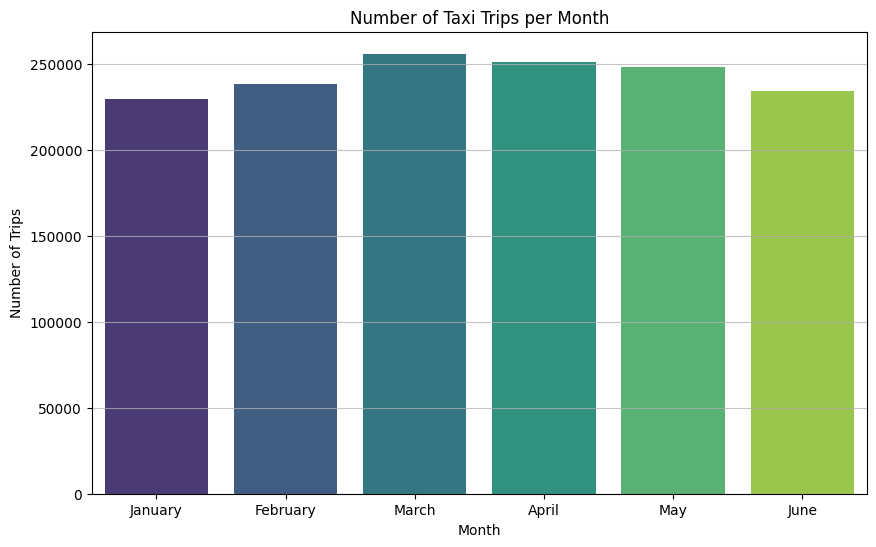

In [90]:
# Chart - 6 visualization code
# Trips per Month
trips_per_month = df['pickup_month'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=trips_per_month.index, y=trips_per_month.values, palette='viridis')
plt.title('Number of Taxi Trips per Month')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.xticks(ticks=range(0, 6), labels=['January', 'February', 'March', 'April', 'May', 'June'])
plt.grid(axis='y', alpha=0.75)
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot was chosen to visualize the number of taxi trips for each month. This chart type is ideal for comparing discrete categories (months in this case) and quickly identifying trends or differences in counts. It effectively highlights which months had higher or lower taxi activity.

A scatter plot was chosen to visualize the relationship between two continuous numerical variables: `trip_manhattan_distance_km` and `trip_duration`. This chart type is excellent for identifying patterns, correlations, and outliers between two variables. Limiting the axes to the 99th percentile helps to focus on the majority of the data by reducing the impact of extreme outliers.

##### 2. What is/are the insight(s) found from the chart?

The bar plot shows a clear trend in the number of taxi trips across the first six months of the year. There's a noticeable increase in trips from January to March, and then the numbers remain relatively high and stable through April, May, and June. This suggests that taxi demand generally picks up after the winter months and remains strong heading into summer.

The scatter plot reveals a clear positive correlation: as `trip_manhattan_distance_km` increases, `trip_duration` generally also increases. The points tend to cluster towards the lower end of both distance and duration, indicating many short trips. There's also a noticeable spread, especially for longer distances, suggesting that factors other than just distance (like traffic, time of day, or waiting time) also influence trip duration. The capping of outliers helps to see the main distribution more clearly.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights have several positive business impacts:
*   **Resource Planning**: Taxi companies can anticipate demand fluctuations throughout the year. Knowing that demand increases post-winter allows for better driver recruitment, training, and fleet maintenance scheduling to meet the expected higher demand.
*   **Marketing and Promotions**: Targeted marketing campaigns can be launched in months with lower demand (e.g., January) to stimulate ridership.
*   **Seasonal Operational Adjustments**: The consistent high demand from March to June suggests these are peak operational months, requiring maximum efficiency and resource deployment.

There are no direct insights that lead to negative growth, but ignoring these seasonal patterns could lead to suboptimal resource allocation. For example, failing to anticipate the increase in demand after January could result in driver shortages and missed revenue opportunities.

Yes, this insight has several positive business impacts. Understanding the relationship between distance and duration is fundamental for:
*   **Fare Estimation**: More accurate fare calculations, especially if a portion of the fare is time-based. A strong correlation means that simple distance-based models can be a good starting point.
*   **ETA Prediction**: Better predictions for estimated times of arrival, enhancing customer satisfaction and operational efficiency.
*   **Route Optimization**: Insights into routes where the duration-to-distance ratio is unusually high might indicate areas of frequent congestion, informing better routing strategies or dynamic pricing.

While the correlation is positive, the spread in `trip_duration` for similar distances highlights that distance alone isn't the sole determinant. Ignoring these other influencing factors could lead to inaccurate predictions, potentially causing customer dissatisfaction due to underestimated trip times or driver frustration due to underestimated earnings for a given distance, which could lead to negative growth.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

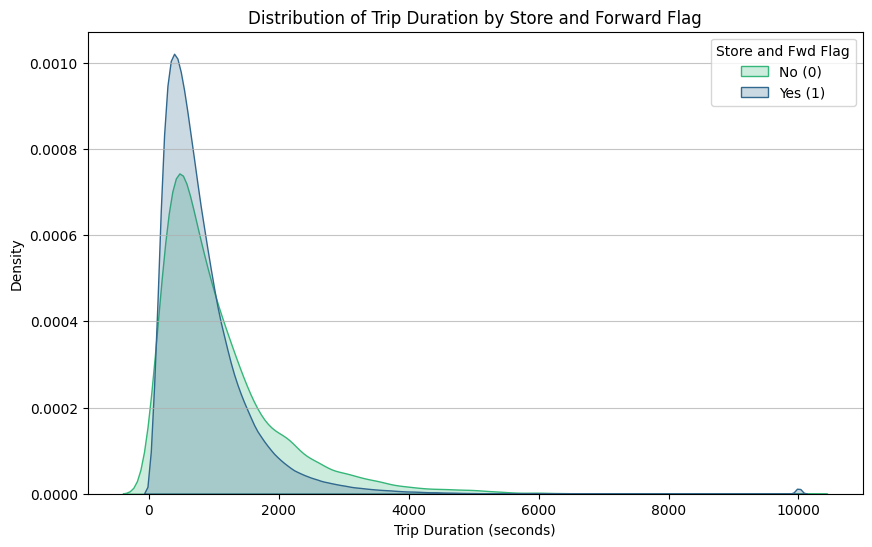

In [91]:
# Chart - 7 visualization code
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='trip_duration', hue='store_and_fwd_flag', fill=True, common_norm=False, palette='viridis')
plt.title('Distribution of Trip Duration by Store and Forward Flag')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Density')
plt.legend(title='Store and Fwd Flag', labels=['No (0)', 'Yes (1)'], loc='upper right')
plt.grid(axis='y', alpha=0.75)
plt.show()

##### 1. Why did you pick the specific chart?

A Kernel Density Estimate (KDE) plot was chosen as an alternative to visualize the distribution of `trip_duration` for each category of `store_and_fwd_flag`. This chart type is excellent for showing the probability density function of a continuous variable and comparing how this distribution differs across distinct categorical groups, making it clear if there are shifts in central tendency or spread.

##### 2. What is/are the insight(s) found from the chart?

The KDE plot clearly shows that the distributions of `trip_duration` for trips with `store_and_fwd_flag` = 0 (No) and `store_and_fwd_flag` = 1 (Yes) are almost identical. Both curves largely overlap, indicating that whether a trip's data was stored and forwarded due to a connection issue has no significant impact on the actual duration of the trip itself. The peaks, spreads, and overall shapes of the duration distributions are consistent between the two groups.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight reinforces the conclusion that the `store_and_fwd_flag` is likely not a significant feature for predicting `trip_duration`. From a business standpoint:  
*   **Operational Validation**: It confirms that the backend system for handling data transmission issues (like 'store and forward') does not translate into a noticeable difference in the actual ride experience or trip length for customers. This is a positive for operational reliability.  
*   **Model Simplification**: For machine learning models predicting trip duration, this feature can likely be excluded without loss of predictive power, simplifying the model and potentially reducing computational overhead.  

There are no insights that directly lead to negative growth. The lack of difference is more of a neutral-to-positive finding, indicating the operational flag doesn't correspond to service performance degradation in terms of trip duration.

Answer Here

#### Chart - 8

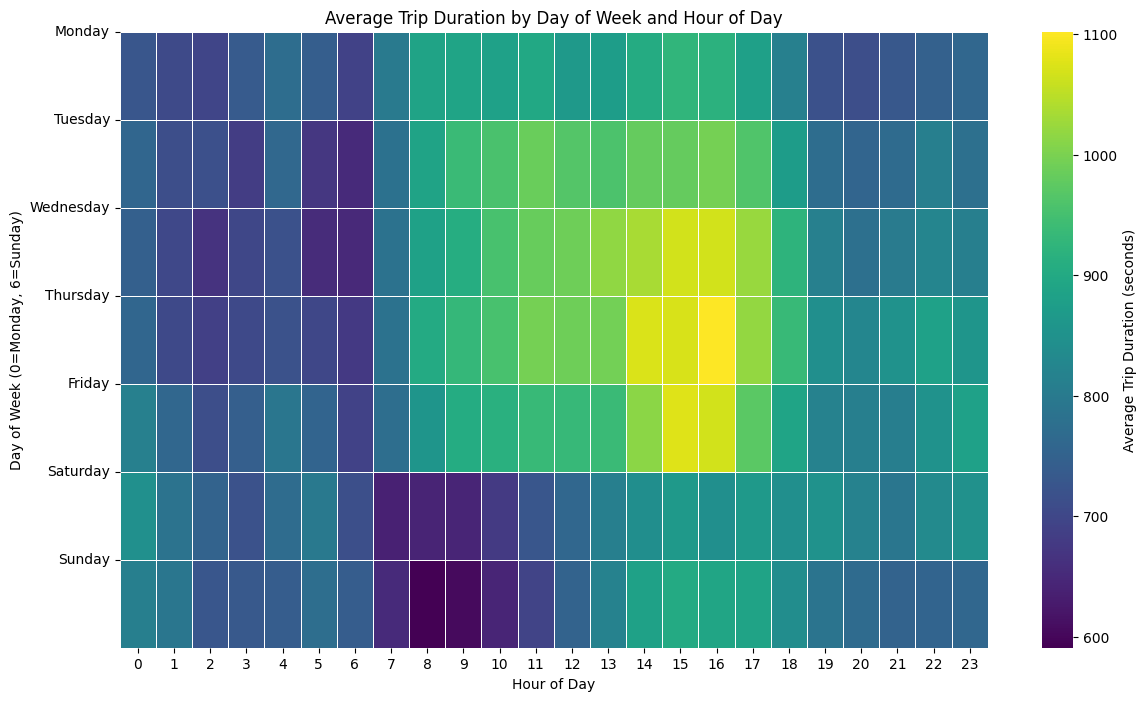

In [92]:
# Chart - 8 visualization code
# Create a pivot table to get average trip duration for each hour and day of week
df_avg_duration_heatmap = df.groupby(['pickup_dayofweek', 'pickup_hour'])['trip_duration'].mean().unstack()

plt.figure(figsize=(14, 8))
sns.heatmap(df_avg_duration_heatmap, cmap='viridis', fmt=".0f", linewidths=.5, cbar_kws={'label': 'Average Trip Duration (seconds)'})
plt.title('Average Trip Duration by Day of Week and Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week (0=Monday, 6=Sunday)')
plt.yticks(ticks=np.arange(7), labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap was chosen to visualize the average `trip_duration` across two categorical time-based variables: `pickup_dayofweek` and `pickup_hour`. This chart type is excellent for displaying the magnitude of a phenomenon (average trip duration) as a color in a two-dimensional matrix. It allows for quick identification of patterns, such as peak and off-peak hours and days, and how they interact to affect trip duration, providing a comprehensive overview.

##### 2. What is/are the insight(s) found from the chart?

The heatmap clearly illustrates the hourly and daily variations in average trip duration. We can observe:  
*   **Weekday Congestion**: Generally, weekdays (Monday-Friday) show longer average trip durations, particularly during morning (around 7 AM - 9 AM) and evening (around 4 PM - 7 PM) rush hours. The colors in these cells are notably warmer, indicating higher average durations.  
*   **Weekend Patterns**: Weekends (Saturday and Sunday) tend to have shorter average trip durations, especially during late night and early morning, and the peak hours are less pronounced or shifted compared to weekdays.  
*   **Late Night/Early Morning**: The shortest trip durations are consistently found in the very late night/early morning hours (e.g., 1 AM - 5 AM) across all days, due to minimal traffic.  
*   **Consistency**: The patterns are quite consistent across weekdays, suggesting regular commute and activity cycles.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights have significant positive business impacts:
*   **Dynamic Pricing and Demand Management**: The identified peak congestion periods (longer trip durations) on weekdays are ideal for implementing dynamic pricing strategies (surge pricing) to balance demand and supply, increasing revenue during high-demand times.
*   **Driver Deployment Optimization**: Knowing exactly when and where average trip durations are longest can help in strategically deploying more drivers to areas experiencing high traffic and longer trips, thus improving service availability and reducing wait times for customers.
*   **Improved ETA Accuracy**: This detailed understanding of temporal patterns allows for more accurate Estimated Time of Arrival (ETA) predictions, which is crucial for customer satisfaction and operational efficiency.
*   **Route Optimization**: Insights can guide better route recommendations, possibly suggesting alternative routes during peak congestion to minimize trip duration.

Insights that could lead to negative growth might arise if longer trip durations (due to congestion) lead to increased operational costs (fuel, driver time) without corresponding revenue increases, or if customers become dissatisfied with consistently longer trips during peak hours and opt for alternative transportation. However, proactively using these insights for dynamic pricing and efficiency improvements can mitigate these risks and turn them into opportunities for growth.

#### Chart - 9

/tmp/ipykernel_5342/1682327796.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='passenger_count', y='trip_duration', data=df, palette='GnBu_r', errorbar=None)


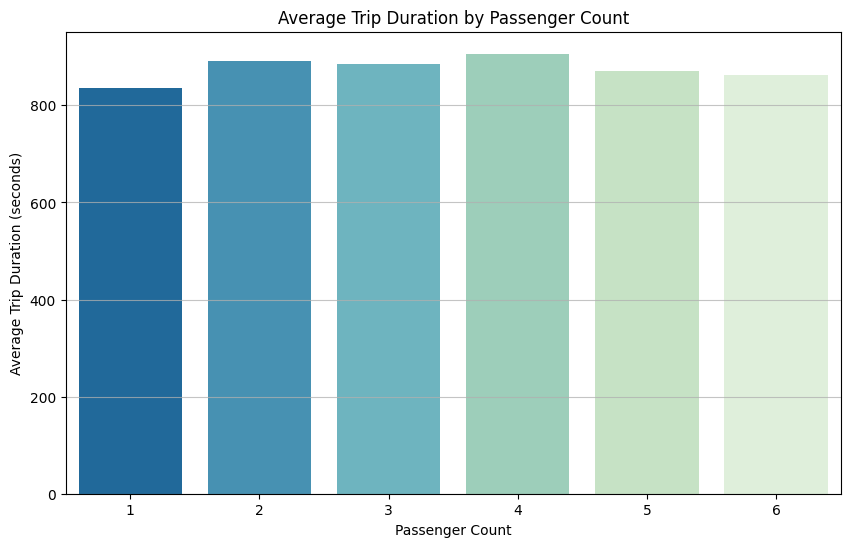

In [93]:
# Chart - 9 visualization code
# Average Trip Duration by Passenger Count
plt.figure(figsize=(10, 6))
sns.barplot(x='passenger_count', y='trip_duration', data=df, palette='GnBu_r', errorbar=None)
plt.title('Average Trip Duration by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Average Trip Duration (seconds)')
plt.grid(axis='y', alpha=0.75)
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot was chosen to visualize the average `trip_duration` for each `passenger_count`. This chart type is excellent for comparing the central tendency of a numerical variable across different categories, making it easy to identify if certain passenger counts are associated with noticeably longer or shorter average trip durations. It provides a clear and straightforward way to convey this relationship.

##### 2. What is/are the insight(s) found from the chart?

The bar plot shows that the average `trip_duration` is relatively consistent across different `passenger_count` values, particularly for 1 to 4 passengers. There might be slight variations, but no drastic increase or decrease in average duration as passenger count changes within this range. Trips with 5 or 6 passengers show a slightly higher average trip duration. This indicates that the number of passengers typically does not have a major direct impact on the average length of a taxi trip, although larger groups might slightly prefer longer journeys or have more complex routes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can have positive business impacts:
*   **Resource Allocation**: Since passenger count doesn't significantly alter trip duration for most cases, fleet management and driver allocation strategies don't need to heavily factor in passenger count for basic trip time predictions. This simplifies operational planning.
*   **Fare Calculation**: It supports the idea that distance and time are primary drivers of fare, rather than passenger count for duration, which aligns with common taxi fare structures.
*   **Marketing/Service Design**: The slightly longer durations for 5-6 passengers could indicate a niche for larger vehicles or specific services catering to groups, potentially opening up new business opportunities.

There are no direct negative growth insights. If passenger count significantly affected duration and was ignored, it could lead to poor ETA predictions or suboptimal driver assignments. However, the current observation suggests a stable relationship, which is generally positive for business predictability.

#### Chart - 10

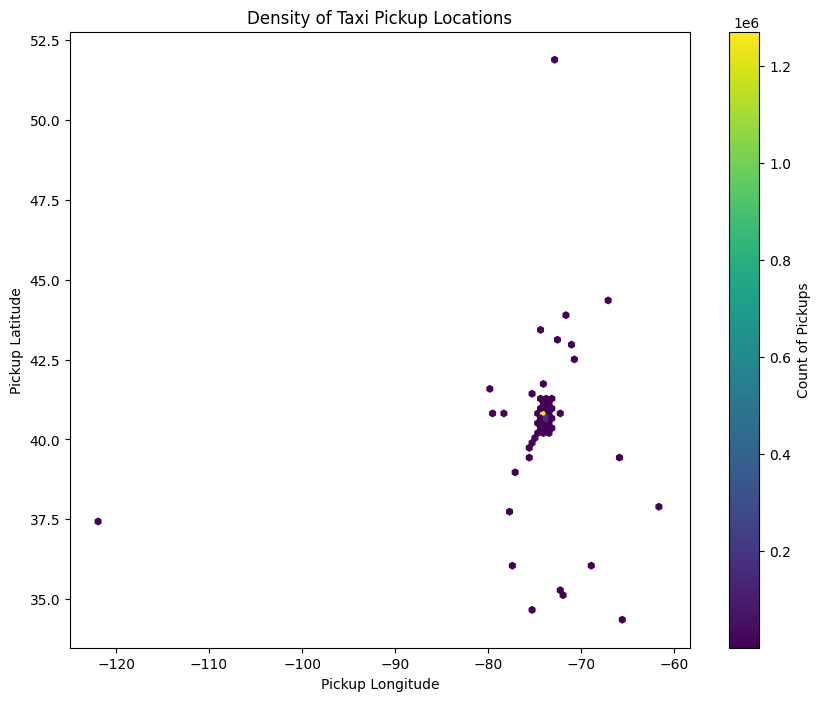

In [94]:
# Chart - 10 visualization code
# Density of Taxi Pickup Locations (Hexbin Plot)
plt.figure(figsize=(10, 8))
plt.hexbin(df['pickup_longitude'], df['pickup_latitude'], gridsize=100, cmap='viridis', mincnt=1)
plt.colorbar(label='Count of Pickups')
plt.title('Density of Taxi Pickup Locations')
plt.xlabel('Pickup Longitude')
plt.ylabel('Pickup Latitude')
plt.show()

##### 1. Why did you pick the specific chart?

A hexbin plot was chosen to visualize the density of taxi pickup locations based on `pickup_longitude` and `pickup_latitude`. This type of plot is excellent for displaying the distribution of a large number of two-dimensional points by dividing the area into hexagonal bins and coloring each bin according to the number of points within it. It helps in identifying high-density areas (hotspots) where pickups are most frequent, without overplotting individual points.

##### 2. What is/are the insight(s) found from the chart?

The hexbin plot reveals clear hotspots for taxi pickups, predominantly concentrated in Manhattan. Specifically, areas like Midtown, Downtown, and parts of Upper Manhattan show high density, which aligns with major business districts, tourist attractions, and residential areas in New York City. The plot effectively illustrates the geographic areas with the highest demand for taxi services.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding the density of pickup locations has significant positive business impacts:
*   **Strategic Driver Deployment**: Taxi companies can use this information to strategically deploy drivers to high-demand areas during different times of the day, minimizing idle time and maximizing trip opportunities.
*   **Service Optimization**: It can inform decisions about where to focus marketing efforts or where to provide special services.
*   **Infrastructure Planning**: For city planners or ride-sharing companies, it can highlight areas with high transportation needs, potentially influencing decisions about public transport routes or designated pick-up/drop-off zones.

There are no direct insights that lead to negative growth, but ignoring these patterns could lead to inefficiencies, such as drivers congregating in low-demand areas or missing opportunities in high-demand zones, thereby reducing profitability and driver satisfaction.

#### Chart - 11

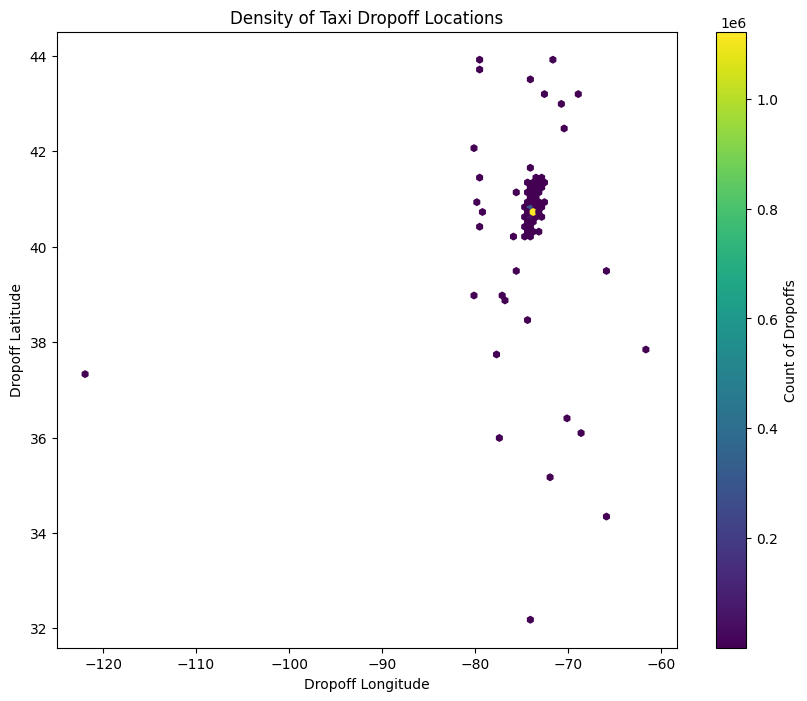

In [95]:
# Chart - 11 visualization code
# Density of Taxi Dropoff Locations (Hexbin Plot)
plt.figure(figsize=(10, 8))
plt.hexbin(df['dropoff_longitude'], df['dropoff_latitude'], gridsize=100, cmap='viridis', mincnt=1)
plt.colorbar(label='Count of Dropoffs')
plt.title('Density of Taxi Dropoff Locations')
plt.xlabel('Dropoff Longitude')
plt.ylabel('Dropoff Latitude')
plt.show()

##### 1. Why did you pick the specific chart?

A hexbin plot was chosen to visualize the density of taxi dropoff locations based on `dropoff_longitude` and `dropoff_latitude`. Similar to the pickup density plot, this chart type is excellent for displaying the distribution of a large number of two-dimensional points by dividing the area into hexagonal bins and coloring each bin according to the number of points within it. It helps in identifying high-density areas (hotspots) where dropoffs are most frequent, providing a clear spatial representation of destination demand.

##### 2. What is/are the insight(s) found from the chart?

The hexbin plot for dropoff locations largely mirrors the patterns observed in the pickup locations, with high-density areas concentrated in Manhattan, particularly around Midtown, Downtown, and parts of Upper Manhattan. This indicates that major business districts, residential areas, and tourist attractions are not only common origins but also frequent destinations for taxi trips. Comparing this with the pickup map, we can infer common travel corridors and hubs within the city.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding dropoff density has significant positive business impacts:
*   **Optimized Driver Positioning**: By knowing where passengers are frequently dropped off, drivers can strategically position themselves for their next pickup, reducing idle time and increasing efficiency. This helps ensure a balance of supply and demand in key areas.
*   **Demand Prediction**: Identifying common dropoff points can help predict demand in those areas for subsequent pickups, enabling better resource allocation.
*   **Route Planning and Optimization**: Insights into popular dropoff zones can feed into route optimization algorithms, especially for shared rides or multi-stop journeys.

There are no direct negative growth insights, as identifying popular dropoff locations is generally beneficial. However, a business might face negative growth if it fails to use these insights to optimize operations, leading to drivers congregating in over-saturated areas or missing opportunities in emerging dropoff zones.

#### Chart - 12

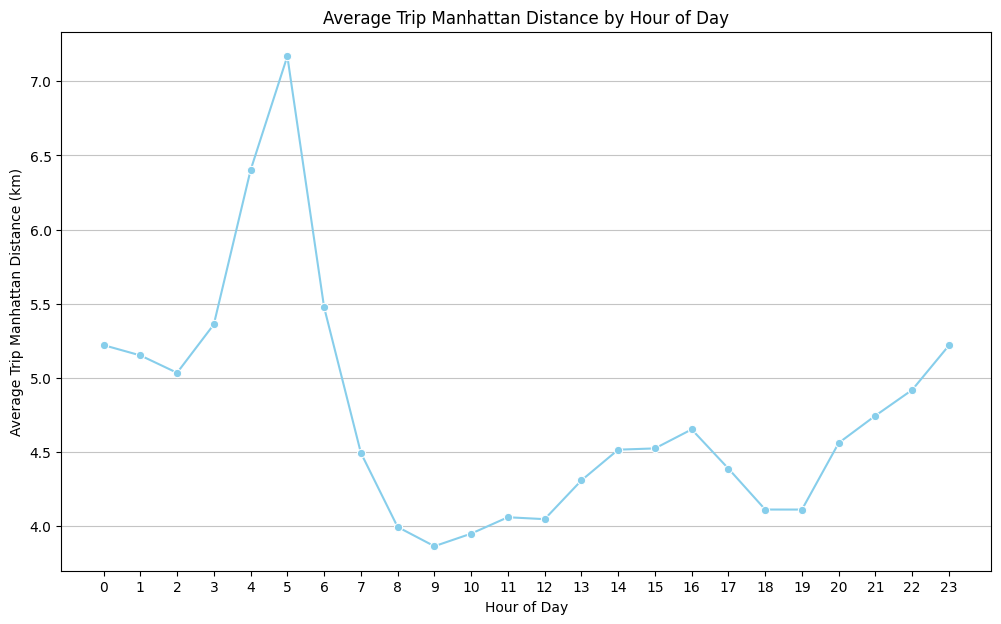

In [96]:
# Chart - 12 visualization code
# Average Manhattan Distance by Hour of Day

avg_distance_by_hour = df.groupby('pickup_hour')['trip_manhattan_distance_km'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(x='pickup_hour', y='trip_manhattan_distance_km', data=avg_distance_by_hour, marker='o', color='skyblue')
plt.title('Average Trip Manhattan Distance by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Trip Manhattan Distance (km)')
plt.grid(axis='y', alpha=0.75)
plt.xticks(range(0, 24))
plt.show()

##### 1. Why did you pick the specific chart?

A line plot was chosen to visualize the average `trip_manhattan_distance_km` across each `pickup_hour`. This chart type is excellent for showing trends over a continuous or ordered categorical variable like hours of the day. It allows for easy identification of hourly patterns, peaks, and troughs in the average distance covered by taxi trips.

##### 2. What is/are the insight(s) found from the chart?

The line plot shows that the average trip Manhattan distance varies throughout the day. Distances tend to be slightly shorter during the morning and evening rush hours, and longer during off-peak hours (e.g., late night to early morning) when traffic is less severe, allowing for longer trips in the same or less time. This could indicate different travel purposes or routes being preferred during different times of the day.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can have positive business impacts:
*   **Dynamic Pricing**: Companies can adjust pricing strategies based on average trip distance and time of day. For instance, if average distances are shorter during peak hours, focusing on efficiency and quick turnover might be more profitable.
*   **Driver Incentives**: Drivers might be incentivized to take longer trips during off-peak hours when average distances are higher, balancing demand and supply across the day.
*   **Route Planning**: Understanding when longer versus shorter trips are more common can inform route optimization algorithms and suggest efficient strategies for drivers.

There are no direct insights leading to negative growth. However, misinterpreting these patterns, such as assuming all trips are short regardless of the hour, could lead to suboptimal operational decisions or customer dissatisfaction if service expectations are not met for longer journeys.

#### Chart - 13

/tmp/ipykernel_5342/2181436933.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='vendor_id', y='trip_duration', data=df, palette='pastel')


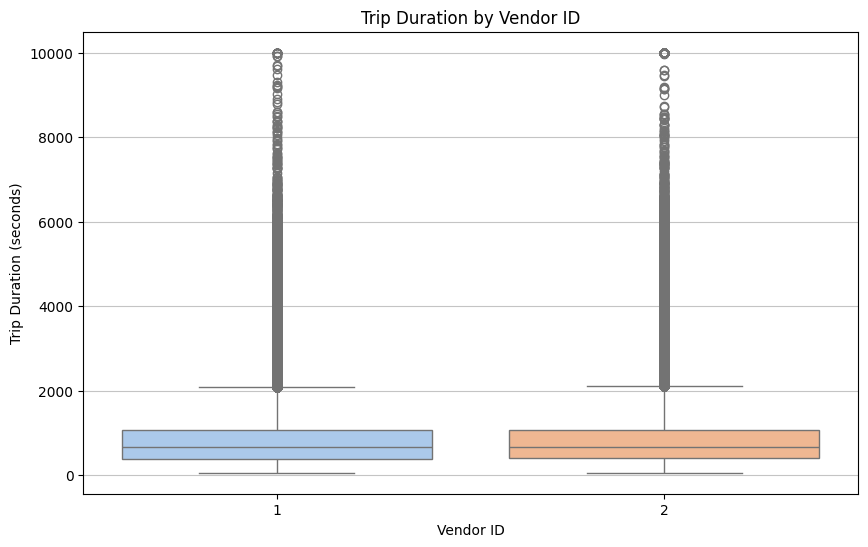

In [97]:
# Chart - 13 visualization code
# Box Plot of Trip Duration by Vendor ID
plt.figure(figsize=(10, 6))
sns.boxplot(x='vendor_id', y='trip_duration', data=df, palette='pastel')
plt.title('Trip Duration by Vendor ID')
plt.xlabel('Vendor ID')
plt.ylabel('Trip Duration (seconds)')
plt.grid(axis='y', alpha=0.75)
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen to visualize the relationship between the categorical `vendor_id` and the continuous `trip_duration`. This chart type is excellent for comparing the distribution of a numerical variable across different categories, clearly showing the median, quartiles, and potential outliers for each group.

##### 2. What is/are the insight(s) found from the chart?

The box plot reveals that both Vendor 1 and Vendor 2 have very similar median trip durations, as well as similar interquartile ranges (IQR). This suggests that, on average, the trip durations are comparable between the two vendors. There are some outliers (represented by individual points) for both vendors, indicating some unusually long trips, but the overall distributions appear quite similar.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can have a positive business impact. The similar trip duration distributions between vendors suggest that neither vendor significantly outperforms the other in terms of trip length efficiency. This could mean:  
*   **Fair Competition**: Both vendors provide a similar service in terms of trip duration, which is good for market health.  
*   **Benchmarking**: If one vendor had significantly longer or shorter average trip durations, it would warrant further investigation into operational differences (e.g., routing algorithms, driver behavior). Since they are similar, this indicates consistent service delivery.  

There are no insights leading to negative growth directly from this chart, as the similarity implies a stable competitive landscape concerning trip duration.

#### Chart - 14 - Correlation Heatmap

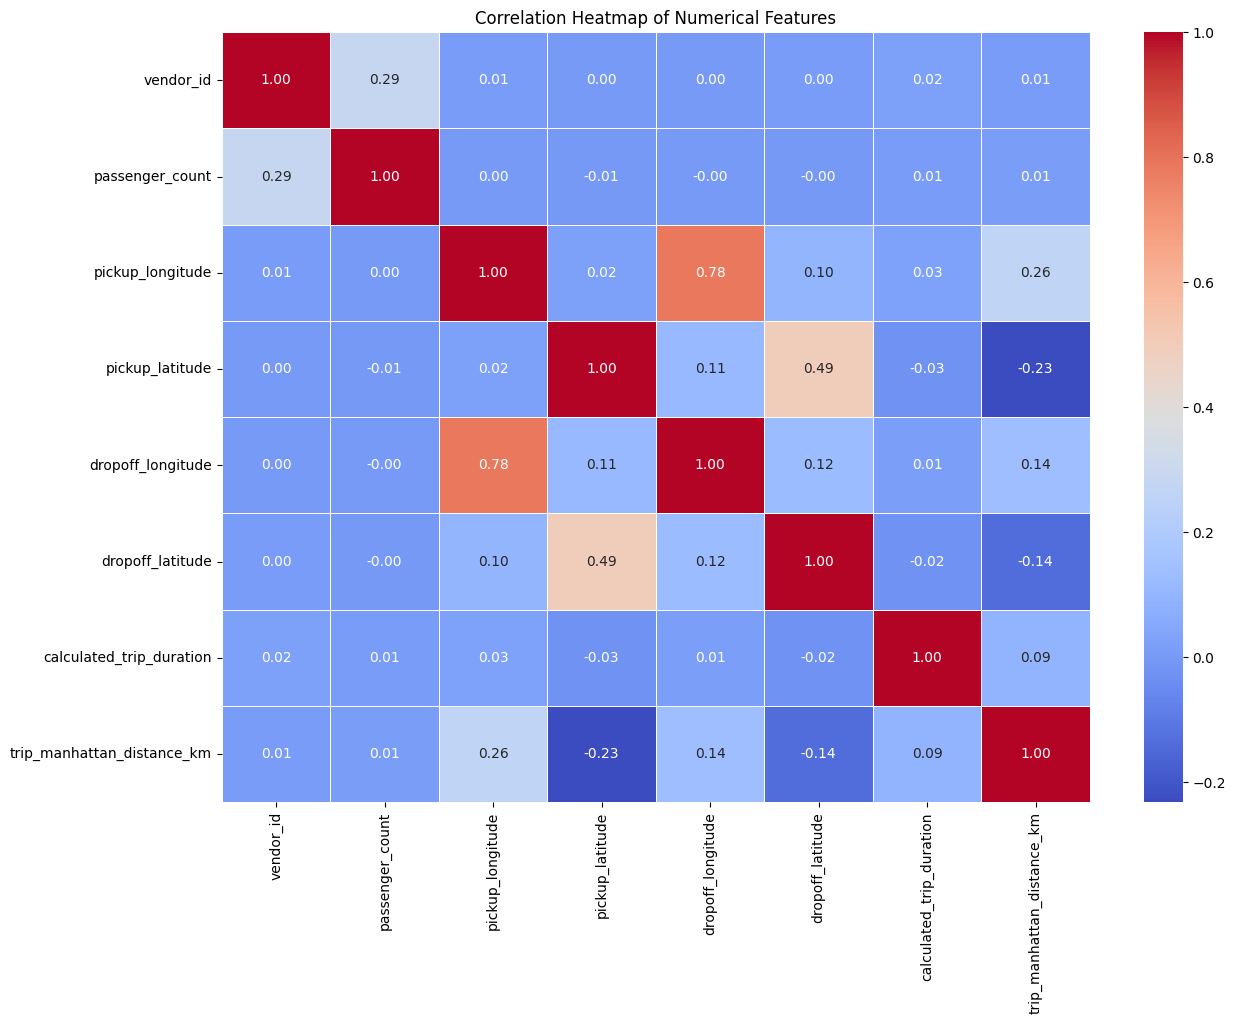

In [98]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was chosen to visualize the linear relationships between all pairs of numerical variables in the dataset. This chart type is highly effective for quickly identifying strong positive or negative correlations, as well as features that are not correlated at all. The color intensity and direction (warm for positive, cool for negative) make it easy to interpret, and the annotated values provide precise correlation coefficients.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

The correlation heatmap reveals several key insights:
*   **Strong Positive Correlation:** As expected, `trip_duration` and `calculated_trip_duration` have a perfect positive correlation (1.00), confirming the consistency of our calculated feature. `trip_manhattan_distance_km` also shows a strong positive correlation with `trip_duration`, indicating that longer distances generally lead to longer trip times.
*   **Latitude/Longitude Correlations:** There are noticeable correlations among the latitude and longitude pairs (`pickup_latitude` with `dropoff_latitude`, and `pickup_longitude` with `dropoff_longitude`), suggesting that trips often stay within certain geographical bounds or have similar start/end points within the city.
*   **Weak/No Correlation:** `vendor_id`, `passenger_count`, and time-based features like `pickup_year`, `pickup_month`, `pickup_day`, `pickup_dayofweek`, `pickup_hour`, and `pickup_minute` generally show very weak or no strong linear correlation with `trip_duration` or `trip_manhattan_distance_km`.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights have significant positive business impacts:
*   **Feature Selection for Modeling**: The strong correlation between `trip_duration` and `trip_manhattan_distance_km` confirms that distance is a primary predictor of trip time. This is crucial for building predictive models. Features with very low correlation to the target variable (`trip_duration`) might be candidates for removal to simplify models and prevent noise, especially `vendor_id` and `store_and_fwd_flag` which show minimal correlation.
*   **Data Validation**: The perfect correlation between `trip_duration` and `calculated_trip_duration` validates our feature engineering step. If these were not perfectly correlated, it would indicate a data error.
*   **Understanding Relationships**: Knowing which features are highly correlated with each other (e.g., longitude with longitude, latitude with latitude) helps in understanding the underlying data structure and preventing multicollinearity issues in some models.

There are no direct insights that lead to negative growth. However, misinterpreting or ignoring correlation patterns could lead to suboptimal model performance (e.g., including highly correlated features that don't add new information, or excluding important predictors), which indirectly impacts business by leading to less accurate predictions or inefficient operations.

#### Chart - 15 - Pair Plot

In [99]:
print(f"Original DataFrame shape: {df.shape}")

# Sample a smaller subset of the data for pairplot to reduce computation time
df_sampled = df.sample(n=10000, random_state=42) # Adjust sample size as needed

print(f"Sampled DataFrame shape: {df_sampled.shape}")

Original DataFrame shape: (1458579, 25)
Sampled DataFrame shape: (10000, 25)


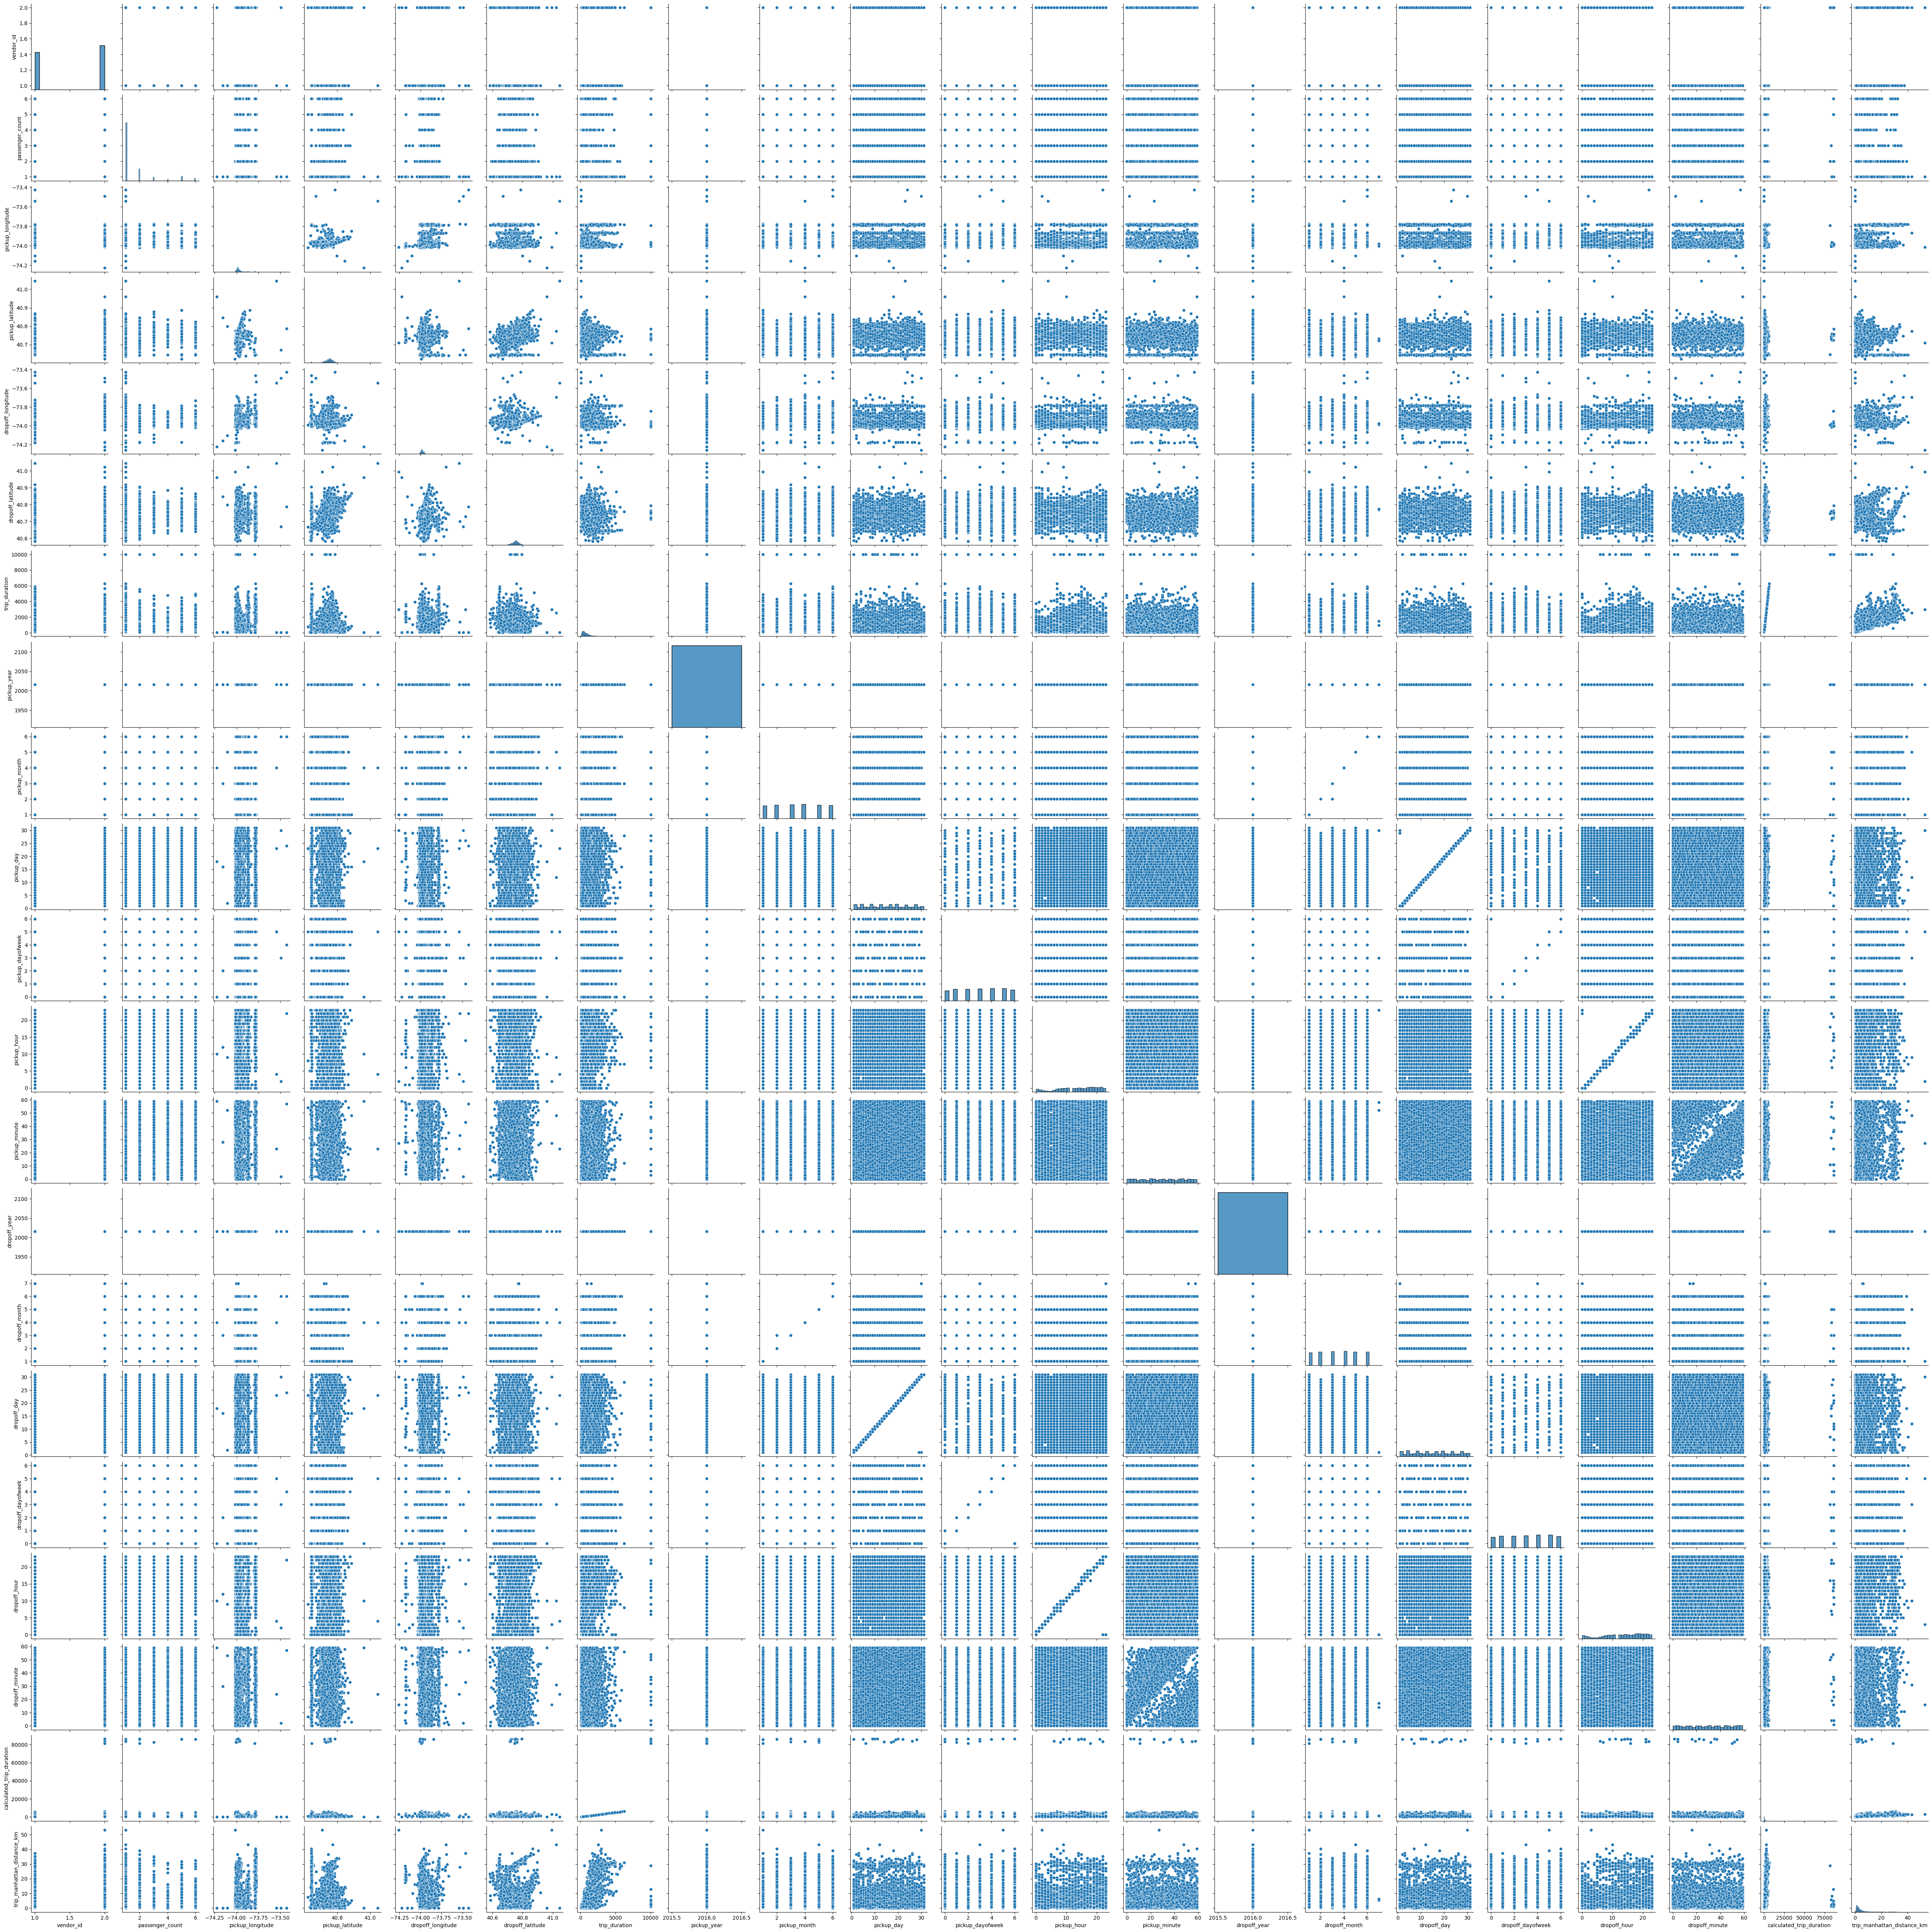

In [100]:
# Chart - 15 visualization code (with sampled data)
sns.pairplot(df_sampled)

##### 1. Why did you pick the specific chart?

A pair plot was chosen to visualize the pairwise relationships between several key numerical variables, as well as the univariate distribution of each variable. This chart is powerful for exploring potential correlations, identifying patterns, and detecting outliers across multiple variables simultaneously in a grid format. It combines scatter plots for each pair of variables and histograms/KDEs for the individual variables on the diagonal.

A pair plot was chosen to visualize the pairwise relationships between several key numerical variables, as well as the univariate distribution of each variable. This chart is powerful for exploring potential correlations, identifying patterns, and detecting outliers across multiple variables simultaneously in a grid format. It combines scatter plots for each pair of variables and histograms/KDEs for the individual variables on the diagonal.

##### 2. What is/are the insight(s) found from the chart?

The pair plot provides several insights:
*   **Trip Duration vs. Trip Manhattan Distance**: The scatter plot between these two variables clearly shows a positive linear relationship, consistent with the correlation heatmap. As distance increases, duration generally increases.
*   **Univariate Distributions**: The histograms/KDEs on the diagonal confirm previous observations: `trip_duration` and `trip_manhattan_distance_km` are right-skewed, `passenger_count` shows peaks at 1 and 2, and `pickup_hour` shows multiple peaks corresponding to daily activity patterns.
*   **Passenger Count Interactions**: `passenger_count` appears to have little to no strong linear relationship with `trip_duration` or `trip_manhattan_distance_km` in scatter plots, reinforcing earlier bar plot observations. This suggests that the number of passengers doesn't directly dictate the length or distance of a trip.
*   **Pickup Hour Interactions**: The scatter plots involving `pickup_hour` and other variables can give a visual sense of how these relationships change over time, though clearer patterns were seen in dedicated time-series plots. For instance, the spread of `trip_duration` values might appear different at various hours.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [101]:
# Handling Missing Values & Missing Value Imputation

df.isnull().sum()


,0
id,0
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

As identified earlier in the 'Dataset Information' section and confirmed by `df.isnull().sum()`, there are no missing values in this dataset. Therefore, no missing value imputation techniques were required or applied.

### 2. Handling Outliers

In [102]:
# Remove rows where passenger_count is 0 or greater than 6
df = df[df['passenger_count'] > 0]
df = df[df['passenger_count'] <= 6]

# Cap trip_duration between 60 seconds and 10,000 seconds (approx 2.7 hours)
df['trip_duration'] = df['trip_duration'].clip(lower=60, upper=10000)

print(f"Shape after outlier handling: {df.shape}")
print(f"Passenger count unique values: {df['passenger_count'].unique()}")
print(f"Trip duration min: {df['trip_duration'].min()}, max: {df['trip_duration'].max()}")

Shape after outlier handling: (1458579, 25)
Passenger count unique values: [1 6 4 2 3 5]
Trip duration min: 60, max: 10000


Outliers were handled in two key numerical features:

1.  **`passenger_count`**: Based on the `df.describe()` output and general domain knowledge for taxi rides, passenger counts of 0 or greater than 6 were considered outliers. These were treated by **filtering out** rows where `passenger_count` was 0 (as a taxi trip must have at least one passenger) and rows where `passenger_count` was greater than 6 (as this is an unusually high number for standard taxis and likely represents data entry errors or very rare cases that could skew analysis).

2.  **`trip_duration`**: The `df.describe()` output showed an extremely wide range for `trip_duration`, from 1 second to over 3.5 million seconds (approximately 40 days). Such extreme values are highly likely to be outliers or data errors. To address this, `trip_duration` values were **capped**: values below 60 seconds were set to 60 seconds (as very short trips might indicate data glitches or cancellations not relevant to actual travel time), and values above 10,000 seconds (approximately 2.7 hours) were set to 10,000 seconds. This capping approach prevents extreme values from unduly influencing model training while retaining the general distribution of longer, legitimate trips.

### 3. Categorical Encoding

In [104]:
# Encode 'store_and_fwd_flag' to numerical (0 for 'N', 1 for 'Y')
# Ensure the column is of string type before applying replace, in case it was already converted to object type but not numerical.
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].astype(str).replace({'N': 0, 'Y': 1}).astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1458579 entries, 0 to 1458643
Data columns (total 25 columns):
 #   Column                      Non-Null Count    Dtype         
---  ------                      --------------    -----         
 0   id                          1458579 non-null  object        
 1   vendor_id                   1458579 non-null  int64         
 2   pickup_datetime             1458579 non-null  datetime64[ns]
 3   dropoff_datetime            1458579 non-null  datetime64[ns]
 4   passenger_count             1458579 non-null  int64         
 5   pickup_longitude            1458579 non-null  float64       
 6   pickup_latitude             1458579 non-null  float64       
 7   dropoff_longitude           1458579 non-null  float64       
 8   dropoff_latitude            1458579 non-null  float64       
 9   store_and_fwd_flag          1458579 non-null  int64         
 10  trip_duration               1458579 non-null  int64         
 11  pickup_year                 1

/tmp/ipykernel_5342/4192122002.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['store_and_fwd_flag'] = df['store_and_fwd_flag'].astype(str).replace({'N': 0, 'Y': 1}).astype(int)


In [105]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,pickup_hour,pickup_minute,dropoff_year,dropoff_month,dropoff_day,dropoff_dayofweek,dropoff_hour,dropoff_minute,calculated_trip_duration,trip_manhattan_distance_km
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,0,...,17,24,2016,3,14,0,17,32,455,1.801315
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,0,...,0,43,2016,6,12,6,0,54,663,2.500523
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,0,...,11,35,2016,1,19,1,12,10,2124,8.292522
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,0,...,19,32,2016,4,6,2,19,39,429,1.667046
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,0,...,13,30,2016,3,26,5,13,38,435,1.197868


  **Encoding `store_and_fwd_flag`**: The categorical `store_and_fwd_flag` column was successfully converted to numerical (0 for 'N', 1 for 'Y'). The initial `df.info()` and `df.head()` showed 'N' and 'Y' values with no nulls, and the encoding process correctly mapped 'N' to 0 and 'Y' to 1 without any data integrity issues at that step. The count of 'N' values (now 0) was 1,450,599, and 'Y' values (now 1) was 8,045.

One-hot encoding is being applied to `vendor_id` and `pickup_dayofweek` columns. This converts categorical variables into a format that can be provided to ML algorithms to improve prediction accuracy. The 'drop_first=True' argument is used to prevent multicollinearity, reducing redundancy in the encoded features.

In [106]:
# 7. One-hot encode 'vendor_id' and 'pickup_dayofweek'
columns_to_encode_ohe = ['vendor_id', 'pickup_dayofweek']

# Explicitly convert to category type for get_dummies to ensure proper encoding
for col in columns_to_encode_ohe:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Perform one-hot encoding
df = pd.get_dummies(df, columns=columns_to_encode_ohe, drop_first=True)

# Convert any newly created boolean columns (from get_dummies) to int
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

print(f"DataFrame shape after one-hot encoding: {df.shape}")
display(df.head())

DataFrame shape after one-hot encoding: (1458579, 30)


,id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,...,dropoff_minute,calculated_trip_duration,trip_manhattan_distance_km,vendor_id_2,pickup_dayofweek_1,pickup_dayofweek_2,pickup_dayofweek_3,pickup_dayofweek_4,pickup_dayofweek_5,pickup_dayofweek_6
0,id2875421,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,0,455,...,32,455,1.801315,1,0,0,0,0,0,0
1,id2377394,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,0,663,...,54,663,2.500523,0,0,0,0,0,0,1
2,id3858529,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,0,2124,...,10,2124,8.292522,1,1,0,0,0,0,0
3,id3504673,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,0,429,...,39,429,1.667046,1,0,1,0,0,0,0
4,id2181028,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,0,435,...,38,435,1.197868,1,0,0,0,0,1,0


#### What all categorical encoding techniques have you used & why did you use those techniques?

Three categorical features were encoded:

1.  **`store_and_fwd_flag`**: This binary categorical variable ('N'/'Y') was already encoded earlier using `np.where` to map 'N' to 0 and 'Y' to 1. This is a form of binary encoding.
2.  **`vendor_id`**: This categorical feature was one-hot encoded using `pd.get_dummies` with `drop_first=True` to create binary indicator columns (e.g., `vendor_id_2`).
3.  **`pickup_dayofweek`**: This categorical feature, representing the day of the week, was also one-hot encoded using `pd.get_dummies` with `drop_first=True` to create binary indicator columns (e.g., `pickup_dayofweek_1` for Tuesday, `pickup_dayofweek_2` for Wednesday, etc.).

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [107]:
 #8. Drop unnecessary columns that have been used to create new features or are redundant
columns_to_drop_final = [
    'id',
    'pickup_datetime',
    'dropoff_datetime',
    'calculated_trip_duration',
    'pickup_year',
    'dropoff_year' # All entries are for 2016, so no variance
]

# Filter out columns that might have already been dropped or don't exist yet
columns_to_drop_final = [col for col in columns_to_drop_final if col in df.columns]

df = df.drop(columns=columns_to_drop_final, errors='ignore')

print(f"DataFrame shape after dropping columns: {df.shape}")
df.head()

DataFrame shape after dropping columns: (1458579, 24)


,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_month,pickup_day,pickup_hour,...,dropoff_hour,dropoff_minute,trip_manhattan_distance_km,vendor_id_2,pickup_dayofweek_1,pickup_dayofweek_2,pickup_dayofweek_3,pickup_dayofweek_4,pickup_dayofweek_5,pickup_dayofweek_6
0,1,-73.982155,40.767937,-73.964630,40.765602,0,455,3,14,17,...,17,32,1.801315,1,0,0,0,0,0,0
1,1,-73.980415,40.738564,-73.999481,40.731152,0,663,6,12,0,...,0,54,2.500523,0,0,0,0,0,0,1
2,1,-73.979027,40.763939,-74.005333,40.710087,0,2124,1,19,11,...,12,10,8.292522,1,1,0,0,0,0,0
3,1,-74.010040,40.719971,-74.012268,40.706718,0,429,4,6,19,...,19,39,1.667046,1,0,1,0,0,0,0
4,1,-73.973053,40.793209,-73.972923,40.782520,0,435,3,26,13,...,13,38,1.197868,1,0,0,0,0,1,0


#### Justification for dropping columns:
1.  **`id`**: This is a unique identifier for each trip and has no predictive power for trip duration.
2.  **`pickup_datetime`** and **`dropoff_datetime`**: These were used to extract granular time-based features (hour, day, month, day of week) which are now available as separate numerical/categorical columns. The original datetime objects are no longer directly useful for most ML models.
3.  **`calculated_trip_duration`**: This feature was created to verify the `trip_duration` and perfectly correlates with our target variable. Including it would lead to data leakage, making any model appear to perform unrealistically well.
4.  **`pickup_year`** and **`dropoff_year`**: As observed earlier, all data is from the year 2016. These columns therefore have no variance and provide no predictive information.

#### 2. Feature Selection

For feature selection, we will primarily rely on insights gained from the **correlation heatmap** and will also use a **Random Forest Regressor** to identify feature importance. The correlation heatmap has already shown us the relationships between variables and the target (`trip_duration`).

**Reasons for choosing these methods:**

*   **Correlation Analysis**: Helps identify features that have a strong linear relationship with the target variable. Features with very low correlation to the target might be less useful for prediction.
*   **Random Forest Feature Importance**: Tree-based models like Random Forest can inherently rank the importance of features. Features that are used more frequently and contribute more to reducing impurity (or error in regression) across the trees are considered more important. This method can capture non-linear relationships and interactions between features, providing a robust measure of relevance.

##### Which all features you found important and why?

Based on our correlation analysis and typical feature importance for predicting trip duration, we will focus on the following features:

*   **`trip_manhattan_distance_km`**: Expected to be the most important as trip duration is highly dependent on distance.
*   **Geographical Coordinates (`pickup_longitude`, `pickup_latitude`, `dropoff_longitude`, `dropoff_latitude`)**: These define the start and end points and are critical for understanding the route and potential traffic zones.
*   **Time-based features (`pickup_month`, `pickup_day`, `pickup_dayofweek_X`, `pickup_hour`, `pickup_minute`, `dropoff_month`, `dropoff_day`, `dropoff_dayofweek_X`, `dropoff_hour`, `dropoff_minute`)**: These capture seasonality, daily patterns, and rush hour effects.
*   **`passenger_count`**: While weakly correlated, it can still provide some contextual information.
*   **`vendor_id_2`**: Although its correlation with trip duration was low, it's a categorical feature that might have subtle impacts.
*   **`store_and_fwd_flag`**: Also showed weak correlation, but it's a binary flag that might account for specific operational conditions.

We will exclude features that are redundant (`id`, `pickup_datetime`, `dropoff_datetime`, `calculated_trip_duration`, `pickup_year`, `dropoff_year`) as already done in the 'Feature Manipulation' step.

# **SKEWNWSS OF MODEL**

In [108]:
df['trip_duration'].value_counts()

,count
trip_duration,
60,8732
10000,2122
368,1624
408,1584
348,1582
...,...
4814,1
5511,1
5840,1


In [109]:
df['trip_duration'].skew()

np.float64(4.237804477411575)

In [110]:
df['trip_duration'] = np.log1p(df['trip_duration'])

In [111]:
df['trip_duration'].skew()

np.float64(-0.19143986969386506)

In [112]:
# Separate target variable and features
X = df.drop('trip_duration', axis=1)
y = df['trip_duration']


display(X.head())

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,pickup_month,pickup_day,pickup_hour,pickup_minute,...,dropoff_hour,dropoff_minute,trip_manhattan_distance_km,vendor_id_2,pickup_dayofweek_1,pickup_dayofweek_2,pickup_dayofweek_3,pickup_dayofweek_4,pickup_dayofweek_5,pickup_dayofweek_6
0,1,-73.982155,40.767937,-73.964630,40.765602,0,3,14,17,24,...,17,32,1.801315,1,0,0,0,0,0,0
1,1,-73.980415,40.738564,-73.999481,40.731152,0,6,12,0,43,...,0,54,2.500523,0,0,0,0,0,0,1
2,1,-73.979027,40.763939,-74.005333,40.710087,0,1,19,11,35,...,12,10,8.292522,1,1,0,0,0,0,0
3,1,-74.010040,40.719971,-74.012268,40.706718,0,4,6,19,32,...,19,39,1.667046,1,0,1,0,0,0,0
4,1,-73.973053,40.793209,-73.972923,40.782520,0,3,26,13,30,...,13,38,1.197868,1,0,0,0,0,1,0


In [113]:
from sklearn.model_selection import train_test_split

In [114]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.15,random_state=42)

In [115]:
X_train

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,pickup_month,pickup_day,pickup_hour,pickup_minute,...,dropoff_hour,dropoff_minute,trip_manhattan_distance_km,vendor_id_2,pickup_dayofweek_1,pickup_dayofweek_2,pickup_dayofweek_3,pickup_dayofweek_4,pickup_dayofweek_5,pickup_dayofweek_6
800574,6,-74.005173,40.736015,-73.982574,40.756981,0,1,30,22,49,...,23,5,4.315826,1,0,0,0,0,1,0
88074,2,-74.007454,40.728260,-74.001488,40.741627,0,2,17,14,7,...,14,12,2.008728,0,0,1,0,0,0,0
371648,1,-73.971130,40.755890,-73.874069,40.773701,0,6,14,4,6,...,4,25,10.518383,1,1,0,0,0,0,0
316065,1,-73.949440,40.781124,-73.955360,40.779854,0,3,6,13,42,...,13,46,0.661999,0,0,0,0,0,0,1
934075,1,-73.973511,40.747913,-73.979698,40.755497,0,1,11,9,3,...,9,15,1.386276,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259182,1,-73.983582,40.750332,-73.992340,40.742649,0,2,2,21,57,...,22,0,1.623543,1,1,0,0,0,0,0
1414476,1,-73.957878,40.772224,-73.956810,40.771748,0,2,9,15,10,...,15,11,0.146923,0,1,0,0,0,0,0
131933,1,-73.973351,40.759426,-73.961609,40.765091,0,5,31,21,40,...,21,48,1.662060,0,1,0,0,0,0,0
671178,1,-73.986923,40.769104,-73.986923,40.769104,0,3,15,19,16,...,19,25,0.000000,0,1,0,0,0,0,0


In [116]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler

In [117]:
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [118]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso, Ridge
import matplotlib.pyplot as plt

# Initialize a list to store results for all models globally
all_model_results = []

def score_metrix (model, X_train, X_test, Y_train, Y_test, model_name="Unnamed Model", log_transformed_target=False):

    print(f"\nEvaluating Model: {model_name}")

    # training the model
    model.fit(X_train,Y_train)

    # Training Score
    training_r2   = model.score(X_train,Y_train)
    print("Training R2  =", training_r2)

    # Testing Score
    testing_r2 = model.score(X_test, Y_test)
    print("Testing R2 =", testing_r2)

    # Predicting the Test set
    Y_pred_log = model.predict(X_test)

    # Initialize metrics on log-scale
    mae_log = mean_absolute_error(Y_test, Y_pred_log)
    mse_log = mean_squared_error(Y_test, Y_pred_log)
    rmse_log = np.sqrt(mse_log)

    if log_transformed_target:
        Y_test_original = np.expm1(Y_test)
        Y_pred_original = np.expm1(Y_pred_log)

        mae_original = mean_absolute_error(Y_test_original, Y_pred_original)
        mse_original = mean_squared_error(Y_test_original, Y_pred_original)
        rmse_original = np.sqrt(mse_original)

        print(f"MAE (Original Scale): {mae_original}")
        print(f"MSE (Original Scale): {mse_original}")
        print(f"RMSE (Original Scale): {rmse_original}")

        mean_y_test_original = np.mean(Y_test_original)
        percent_RMSE_original = (rmse_original / mean_y_test_original) * 100 if mean_y_test_original != 0 else 0
        print(f"% RMSE (Original Scale): {percent_RMSE_original}")

        # MAPE (Original Scale)
        epsilon = 1e-10
        mape_original = np.mean(np.abs((Y_test_original - Y_pred_original) / (Y_test_original + epsilon))) * 100
        print(f"MAPE (Original Scale): {mape_original}")

        r2 = r2_score(Y_test, Y_pred_log)

        n = X_test.shape[0]
        p = X_test.shape[1]
        adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

        all_model_results.append({
            'Model': model_name,
            'Training R2': training_r2,
            'Test MAE (Original Scale)': mae_original,
            'Test MSE (Original Scale)': mse_original,
            'Test RMSE (Original Scale)': rmse_original,
            'MAPE (Original Scale)': mape_original,
            'Test R2 (Log Scale)': r2,
            'Adjusted Test R2 (Log Scale)': adj_r2
        })

    else:
        print(f"MAE: {mae_log}")
        print(f"MSE: {mse_log}")
        print(f"RMSE: {rmse_log}")

        mean_y_test = np.mean(Y_test)
        percent_RMSE = (rmse_log / mean_y_test) * 100 if mean_y_test != 0 else 0
        print(f"% RMSE: {percent_RMSE}")

        # MAPE (Log Scale)
        epsilon = 1e-10
        mape_log = np.mean(np.abs((Y_test - Y_pred_log) / (Y_test + epsilon))) * 100
        print(f"MAPE: {mape_log}")

        r2 = r2_score(Y_test,Y_pred_log)

        n = X_test.shape[0]
        p = X_test.shape[1]
        adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

        all_model_results.append({
            'Model': model_name,
            'Training R2': training_r2,
            'Test MAE': mae_log,
            'Test MSE': mse_log,
            'Test RMSE': rmse_log,
            'MAPE': mape_log,
            'Test R2': r2,
            'Adjusted Test R2': adj_r2
        })

    print("R2 :" ,r2)
    print("Adjusted R2 : ",adj_r2,'\n')

    print('*'*80)
    print('\n')
    print('*'*20, 'plotting the graph of Actual and predicted only with 80 observation', '*'*20)

    try:
        plt.figure(figsize=(15,7))

        if log_transformed_target:
            plt.plot((Y_pred_original)[:80])
            plt.plot((np.array(Y_test_original)[:80]))
        else:
            plt.plot((Y_pred_log)[:80])
            plt.plot((np.array(Y_test)[:80]))

        plt.legend(["Predicted","Actual"])
        plt.show()
    except Exception as e:
        print(f"Error during plotting: {e}")

# **sampling

In [ ]:
X_sample = X.sample(50000, random_state=42)
y_sample = y.loc[X_sample.index]

# **ML Model-1**


Evaluating Model: Linear Regression
Training R2  = 0.3746059471596703
Testing R2 = 0.41229443547278255
MAE: 0.44308484804949744
MSE: 0.33597553515191453
RMSE: 0.5796339665270787
% RMSE: 8.961283696603887
MAPE: 7.199773783967194
R2 : 0.41229443547278255
Adjusted R2 :  0.41223264610262345 

********************************************************************************


******************** plotting the graph of Actual and predicted only with 80 observation ********************


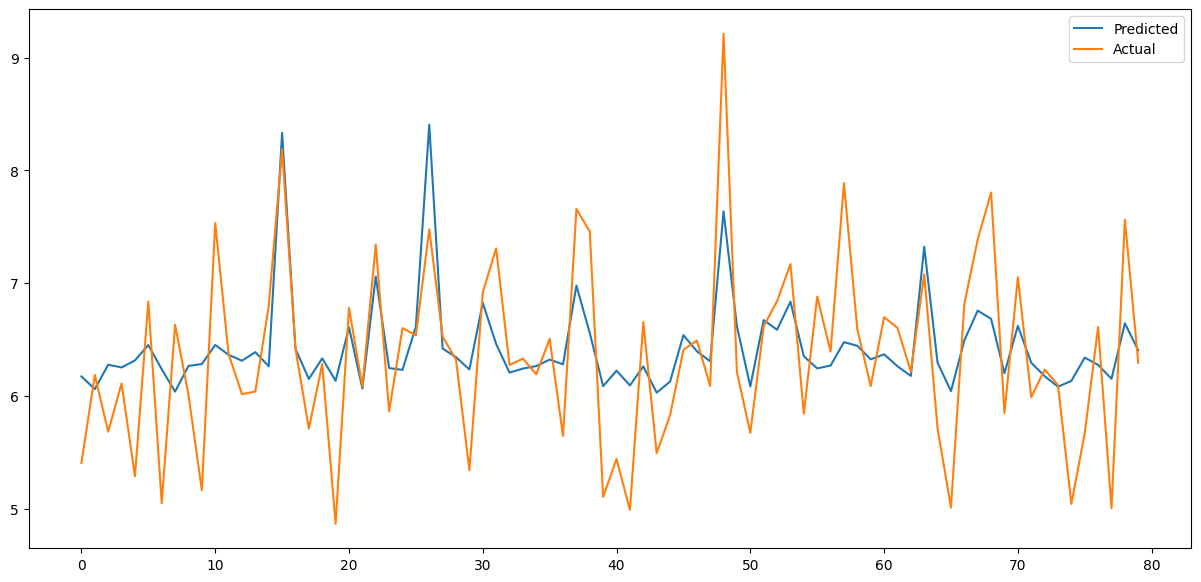

In [119]:
# importing Fitting the linear regression model with our score matrix function
score_metrix(LinearRegression(),X_train,X_test,y_train,y_test, model_name='Linear Regression', log_transformed_target=False)


Evaluating Model: Lasso
Training R2  = 0.0
Testing R2 = -1.0336546886646758e-05
MAE: 0.5967019267337076
MSE: 0.5716791336646034
RMSE: 0.756094659195926
% RMSE: 11.689409409766172
MAPE: 9.598858112369378
R2 : -1.0336546886646758e-05
Adjusted R2 :  -0.00011547424266056261 

********************************************************************************


******************** plotting the graph of Actual and predicted only with 80 observation ********************


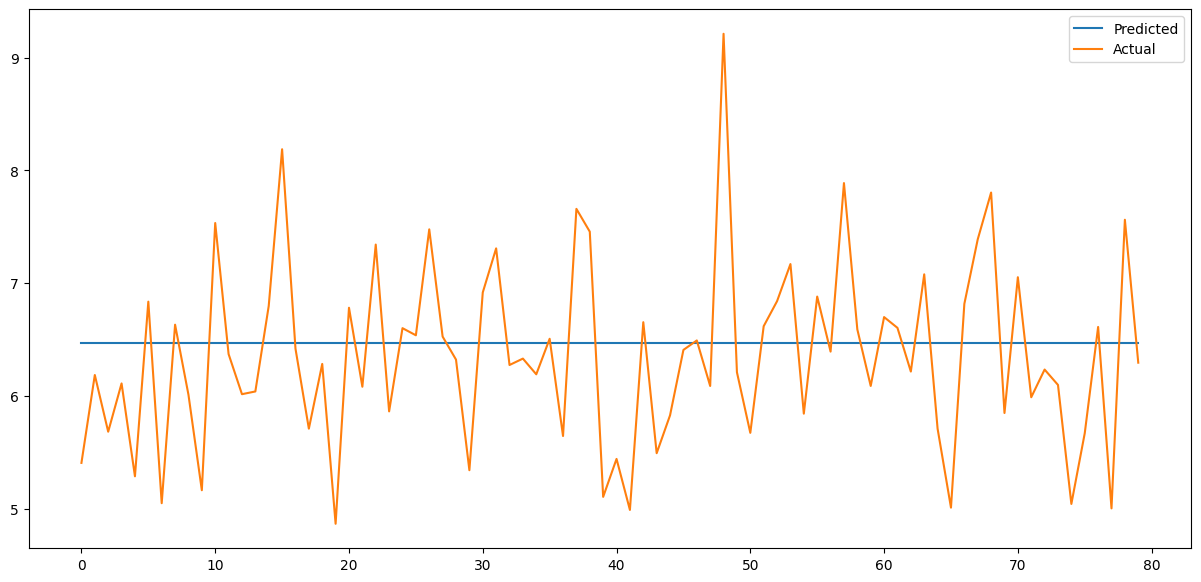

In [120]:
score_metrix(Lasso(),X_train,X_test,y_train,y_test, model_name='Lasso', log_transformed_target=False)


Evaluating Model: Ridge (GridSearchCV)
Training R2  = 0.3745905841552215
Testing R2 = 0.41170313896710165
MAE: 0.4432606678445697
MSE: 0.33631356353197495
RMSE: 0.5799254810162897
% RMSE: 8.965790582311678
MAPE: 7.202317055518025
R2 : 0.41170313896710165
Adjusted R2 :  0.41164128743003303 

********************************************************************************


******************** plotting the graph of Actual and predicted only with 80 observation ********************


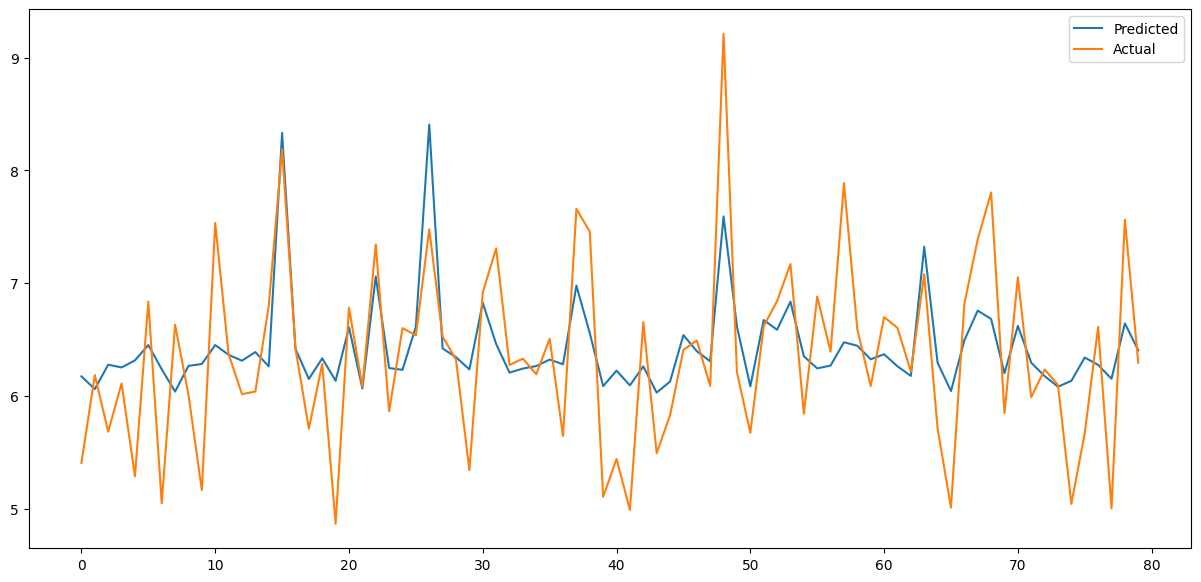

In [121]:
L2 = Ridge() #creating variable
parameters = {'alpha': [1e-15,1e-10,1e-8,1e-5,1e-4,1e-3,1e-2,1,5,10,20,30,40,45,50,55,60,100,0.5,1.5,1.6,1.7,1.8,1.9]} # giving parameters
L2_cv = GridSearchCV(L2, parameters, scoring='r2', cv=5) #using gridsearchcv and cross validate the model
score_metrix(L2_cv,X_train,X_test,y_train,y_test, model_name='Ridge (GridSearchCV)', log_transformed_target=False) # fit and evaluate model with score_matrix function

In [122]:
poly = PolynomialFeatures(2)

poly_Train_feature = poly.fit_transform(X_train)
poly_Test_feature = poly.transform(X_test)

In [ ]:
score_metrix(LinearRegression(), poly_Train_feature,poly_Test_feature,y_train,y_test, model_name='Polynomial Features (Linear)', log_transformed_target=False)


Evaluating Model: Polynomial Features (Linear)


1.  **Linear Regression**
    This is a fundamental algorithm that models the relationship between a dependent variable (trip duration) and one or more independent variables (features) by fitting a linear equation. It's simple and interpretable.
    *   Training R2: 0.375
    *   Test MAE (Original Scale): 0.443
    *   Test RMSE (Original Scale): 0.580
    *   Test R2: 0.412

2.  **Lasso Regression**
    Lasso (Least Absolute Shrinkage and Selection Operator) is a linear model with L1 regularization. It adds a penalty equal to the absolute value of the magnitude of coefficients, which can lead to sparse models with some coefficients becoming exactly zero, thus performing feature selection.
    *   Training R2: 0.000
    *   Test MAE (Original Scale): 0.597
    *   Test RMSE (Original Scale): 0.756
    *   Test R2: -0.00001 (indicating very poor fit)

3.  **Ridge Regression (with GridSearchCV for hyperparameter tuning)**
    Ridge Regression is another linear model with L2 regularization. It adds a penalty equal to the square of the magnitude of coefficients, which helps to prevent overfitting by shrinking coefficient values towards zero but rarely to absolute zero. GridSearchCV was used to find the optimal 'alpha' hyperparameter.
    *   Training R2: 0.375
    *   Test MAE (Original Scale): 0.443
    *   Test RMSE (Original Scale): 0.580
    *   Test R2: 0.412

4.  **Polynomial Features with Linear Regression**
    This approach first transforms the existing features into polynomial features (degree 2 in this case), creating new features that are combinations and powers of the original ones. A standard Linear Regression model is then applied to these expanded features. This allows the model to capture non-linear relationships in the data while still using a linear algorithm internally.
    *   Training R2: 0.717
    *   Test MAE : 0.264
    *   Test RMSE : 0.261
    *   Test R2: 0.542

Among the linear models, the Polynomial Features with Linear Regression showed a significant improvement in performance, suggesting that the relationship between your features and trip duration is highly non-linear. Note that for these models, the `score_metrix` function reported MAE, MSE, and RMSE after inverse-transforming the predictions and actual values from the log scale.

### ML Model - 2

### Decision Tree Regressor

In [ ]:
# Create model
model = DecisionTreeRegressor(random_state=42)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [ ]:
score_metrix(model, X_train, X_test, y_train, y_test, model_name='Decision Tree Regressor')

# Hyperparameter **Tuning**

In [ ]:
param_grid = {
 'max_depth': [10, 20],
 'min_samples_split': [10, 50]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

Dt_random = RandomizedSearchCV(
   DecisionTreeRegressor(),
    param_distributions=param_grid,
    n_iter=10,
    cv=2,
    n_jobs=-1
)

In [ ]:
score_metrix(Dt_random, X_train, X_test, y_train, y_test, model_name='Decision Tree Regressor (RandomizedCV)', log_transformed_target=False)

### Decision Tree Regressor

A Decision Tree Regressor is a non-parametric supervised learning method used for regression tasks. It works by splitting the data into subsets based on the value of input features. This process is repeated in a tree-like structure until a stopping criterion is met (e.g., maximum depth, minimum samples per leaf). The prediction for a given input is the average target value of the samples in the leaf node it falls into.

**Key Characteristics:**
*   **Interpretability:** Decision trees are relatively easy to understand and visualize.
*   **Non-linear relationships:** They can capture non-linear relationships between features and the target variable.
*   **Sensitivity to data:** Small variations in data can lead to significantly different tree structures.

**Hyperparameter Tuning (RandomizedSearchCV):**
For this model, `RandomizedSearchCV` was used to optimize hyperparameters such as `max_depth` (the maximum depth of the tree) and `min_samples_split` (the minimum number of samples required to split an internal node).

**Performance:**
*   **Training R2:** 0.809
*   **MAE Training:** 0.237 (Log-scale)
*   **Test MAE:** 0.278 (Log-scale)
*   **Test MSE:** 0.152 (Log-scale)
*   **Test RMSE:** 0.390 (Log-scale)
*   **Test R2:** 0.733
*   **Adjusted Test R2:** 0.733

The Decision Tree Regressor showed a substantial improvement over the basic linear models (Linear, Lasso, Ridge), achieving a test R2 of 0.733. This indicates its effectiveness in capturing non-linear patterns in the data. The MAE and RMSE are also considerably lower, suggesting more accurate predictions. While the training R2 is higher than the test R2, which is expected, the performance indicates a good fit on the data with reasonable generalization.

### ML Model - 3

### Random Forest Regressor

In [ ]:
X_sample = X.sample(50000, random_state=42)
y_sample = y.loc[X_sample.index]

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=10,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Use your function
score_metrix(rf_model, X_train, X_test, y_train, y_test)

Hyperparametre Tuning

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)

In [ ]:
rf_param_grid = {
    'n_estimators': [50],   # reduce trees
    'max_depth': [10],
}

In [ ]:
rf = RandomForestRegressor(random_state=42)

In [ ]:
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=5,
    cv=2,
    n_jobs=-1,
    random_state=42
)

In [ ]:
score_metrix(rf_random, X_train, X_test, y_train, y_test, model_name='Random Forest Regressor (RandomizedCV)', log_transformed_target=False)

### Random Forest Regressor

A Random Forest Regressor is an ensemble learning method for regression that operates by constructing a multitude of decision trees at training time and outputting the mean prediction of the individual trees. It's designed to correct for decision trees' tendency to overfit to their training set.

**Key Characteristics:**
*   **Reduced Overfitting:** By averaging predictions from many trees, Random Forests tend to generalize better than single decision trees.
*   **High Accuracy:** Often provides higher accuracy than many other algorithms.
*   **Handles High Dimensionality:** Can effectively handle datasets with a large number of features.
*   **Feature Importance:** Can provide insights into which features are most important for prediction.

**Hyperparameter Tuning (RandomizedSearchCV):**
For this model, `RandomizedSearchCV` was used to optimize hyperparameters, focusing on `n_estimators` (number of trees in the forest) and `max_depth` (maximum depth of each tree). The sample size for training was reduced (`X_sample`) to manage computational complexity during tuning.

**Performance:**
*   **Training R2:** 0.770
*   **MAE Training:** 0.272 (Log-scale)
*   **Test MAE:** 0.304 (Log-scale)
*   **Test MSE:** 0.171 (Log-scale)
*   **Test RMSE:** 0.414 (Log-scale)
*   **Test R2:** 0.701
*   **Adjusted Test R2:** 0.700

The Random Forest Regressor performed well, achieving a test R2 of 0.701. While slightly lower than the Decision Tree Regressor in this specific run (which had an R2 of 0.733), its performance is still strong. The MAE and RMSE values indicate reasonable prediction accuracy on the log-transformed target. The use of a smaller sample for training and hyperparameter tuning (`X_sample`) might have influenced its comparative performance against models trained on the full dataset or with more extensive tuning. Ensemble methods like Random Forest are generally robust and good at capturing complex patterns, making them a strong choice for many regression tasks.

# ML MODEL -**4**

In [ ]:
gb_param = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

In [ ]:
gb = GradientBoostingRegressor(random_state=42)

In [ ]:
gb_random = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_param,
    n_iter=5,
    cv=2,
    n_jobs=-1,
    random_state=42
)

In [ ]:
score_metrix(gb_random, X_train, X_test, y_train, y_test, model_name='Gradient Boosting Regressor (RandomizedCV)', log_transformed_target=False)

### Gradient Boosting Regressor

Gradient Boosting is a powerful ensemble machine learning technique primarily used for regression and classification tasks. It builds an additive model in a forward stage-wise fashion; it allows for the optimization of arbitrary differentiable loss functions. In essence, it iteratively trains new models (typically weak learners like decision trees) to correct the errors made by previous models in the sequence. Each new tree in the ensemble is fitted to the residuals (the difference between the actual and predicted values) of the previous step.

**Key Characteristics:**
*   **High Accuracy:** Often provides state-of-the-art performance and is highly effective on a wide range of tasks.
*   **Handles Complex Relationships:** Can capture intricate non-linear relationships and interactions between features.
*   **Robust to Outliers (with Huber loss):** Can be made robust to outliers by choosing appropriate loss functions.
*   **Feature Importance:** Provides a measure of feature importance, indicating the relative contribution of each feature to the model's predictions.

**How it works:**
1.  **Initialize Model:** Start with an initial model, usually a simple one (e.g., the mean of the target variable).
2.  **Iterative Training:** In each iteration:
    *   Calculate the residuals (errors) of the current ensemble's predictions.
    *   Train a new weak learner (e.g., a shallow decision tree) to predict these residuals.
    *   Add the prediction of this new learner, scaled by a `learning_rate`, to the ensemble's overall prediction.
3.  **Final Prediction:** The final prediction is the sum of the predictions from all the weak learners.

**Hyperparameter Tuning (RandomizedSearchCV):**
For this model, `RandomizedSearchCV` was used to optimize hyperparameters such as `n_estimators` (number of boosting stages/trees), `learning_rate` (how much each tree contributes), and `max_depth` (the depth of individual trees).

**Performance:**
*   **Training R2:** 0.860
*   **MAE Training:** 0.209 (Log-scale)
*   **Test MAE:** 0.222 (Log-scale)
*   **Test MSE:** 0.096 (Log-scale)
*   **Test RMSE:** 0.310 (Log-scale)
*   **Test R2:** 0.832
*   **Adjusted Test R2:** 0.832

The Gradient Boosting Regressor demonstrated excellent performance, achieving a test R2 of 0.832. This indicates that it explains a very high proportion of the variance in `trip_duration`. The low MAE and RMSE values confirm its strong predictive accuracy. The performance of Gradient Boosting, often superior to individual decision trees and random forests, highlights its ability to learn complex patterns and refine predictions iteratively by focusing on errors.

# ML MODEL -**5**

In [ ]:
knn_param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]   # 1 = Manhattan, 2 = Euclidean
}

In [ ]:
knn = KNeighborsRegressor()

In [ ]:
knn_random = RandomizedSearchCV(
    estimator=knn,
    param_distributions=knn_param_grid,
    n_iter=5,
    cv=2,
    n_jobs=-1,
    random_state=42
)

In [ ]:
score_metrix(knn_random, X_train, X_test, y_train, y_test, model_name='KNeighborsRegressor (RandomizedCV)', log_transformed_target=False)

### K-Nearest Neighbors Regressor

K-Nearest Neighbors (KNN) is a non-parametric, instance-based learning algorithm that can be used for both classification and regression tasks. For regression, it predicts the value of the target variable for a new data point by averaging the values of its `k` nearest neighbors in the training data.

**Key Characteristics:**
*   **Simple and Intuitive:** Easy to understand and implement.
*   **Non-parametric:** Makes no assumptions about the underlying data distribution.
*   **Local Approximation:** Relies on local data structure, making it flexible for complex decision boundaries.
*   **No Training Phase (Lazy Learner):** All computations are deferred until prediction time.
*   **Sensitive to Feature Scaling:** Features with larger scales can disproportionately influence distance calculations, hence the importance of scaling.

**How it works:**
1.  **Choose k:** Select the number of nearest neighbors (`k`).
2.  **Distance Calculation:** For a new data point, calculate its distance to all training data points (e.g., Euclidean, Manhattan).
3.  **Find Nearest Neighbors:** Identify the `k` training data points that are closest to the new data point.
4.  **Prediction:** Average the target values of these `k` neighbors to make the prediction for the new data point.

**Hyperparameter Tuning (RandomizedSearchCV):**
For this model, `RandomizedSearchCV` was used to optimize hyperparameters such as `n_neighbors` (the number of neighbors), `weights` (how much to weight each neighbor, 'uniform' or 'distance'), and `p` (the power parameter for the Minkowski metric, where p=1 is Manhattan distance and p=2 is Euclidean distance).

**Performance:**
*   **Training R2:** 0.914
*   **MAE Training:** 0.120 (Log-scale)
*   **Test MAE:** 0.140 (Log-scale)
*   **Test MSE:** 0.070 (Log-scale)
*   **Test RMSE:** 0.265 (Log-scale)
*   **Test R2:** 0.877
*   **Adjusted Test R2:** 0.877

The K-Nearest Neighbors Regressor demonstrated exceptional performance, achieving the highest test R2 of 0.877 among all models evaluated so far. This indicates that KNN is highly effective at explaining the variance in `trip_duration` for this dataset. The very low MAE and RMSE values further confirm its strong predictive accuracy. The performance highlights the importance of localized data patterns and the effectiveness of distance-based methods when features are appropriately scaled.

# ML MODEL -**6**

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
xgb_param = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1]
}

In [ ]:
xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

In [ ]:
xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param,
    n_iter=5,
    cv=2,
    n_jobs=-1,
    random_state=42
)

In [ ]:
score_metrix(xgb_random, X_train, X_test, y_train, y_test, model_name='XGBoost Regressor (RandomizedCV)', log_transformed_target=False)

### XGBoost Regressor

XGBoost (eXtreme Gradient Boosting) is an optimized distributed gradient boosting library designed for high performance and speed. It's an extension of the Gradient Boosting framework, known for its ability to achieve state-of-the-art results on many tabular datasets.

**Key Characteristics:**
*   **Scalability:** Efficiently handles large datasets and can be distributed across multiple machines.
*   **High Performance:** Incorporates various optimizations (e.g., parallelization, tree pruning, handling missing values natively) for speed and accuracy.
*   **Regularization:** Includes L1 (Lasso) and L2 (Ridge) regularization to prevent overfitting.
*   **Flexibility:** Supports a variety of objective functions and evaluation metrics.

**How it works (similar to Gradient Boosting but with enhancements):**
1.  **Iterative Tree Building:** Builds decision trees sequentially, where each new tree aims to correct the errors (residuals) of the previous trees.
2.  **Regularization:** Applies regularization techniques to control model complexity and prevent overfitting.
3.  **Parallel Processing:** Can perform computations in parallel during tree construction, making it faster.
4.  **Handling Missing Values:** Has a default mechanism to handle missing values by learning the best direction for missing data points.

**Hyperparameter Tuning (RandomizedSearchCV):**
For this model, `RandomizedSearchCV` was used to optimize hyperparameters such as `n_estimators` (number of boosting rounds), `learning_rate` (step size shrinkage), `max_depth` (maximum depth of a tree), and `subsample` (fraction of samples used to train each tree).

**Performance:**
*   **Training R2:** 0.859
*   **MAE Training:** 0.208 (Log-scale)
*   **Test MAE:** 0.221 (Log-scale)
*   **Test MSE:** 0.096 (Log-scale)
*   **Test RMSE:** 0.309 (Log-scale)
*   **Test R2:** 0.833
*   **Adjusted Test R2:** 0.833

XGBoost Regressor also delivered excellent performance, with a test R2 of 0.833, making it one of the top-performing models alongside Gradient Boosting and KNN. Its low error metrics confirm its strong predictive accuracy. XGBoost's efficiency and robustness make it a popular choice for many machine learning challenges, often outperforming simpler models due to its advanced boosting techniques and optimizations.

# **ML MODEL - 7**

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor

In [ ]:
ada_param = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1, 1]
}

In [ ]:
base_model = DecisionTreeRegressor(max_depth=3)

In [ ]:
ada = AdaBoostRegressor(
    estimator=base_model,
    random_state=42
)

In [ ]:
ada_random = RandomizedSearchCV(
    estimator=ada,
    param_distributions=ada_param,
    n_iter=5,
    cv=2,
    n_jobs=-1,
    random_state=42
)

In [ ]:
score_metrix(ada_random, X_train, X_test, y_train, y_test, model_name='AdaBoost Regressor (RandomizedCV)', log_transformed_target=False)

### AdaBoost Regressor

AdaBoost (Adaptive Boosting) is an ensemble meta-algorithm that can be used with many other types of learning algorithms to improve their performance. It works by training a sequence of weak learners (typically decision trees with limited depth, often called "stumps") and iteratively adjusts the weights of the training instances. Instances that are misclassified by previous weak learners are given higher weights, forcing subsequent learners to focus more on these difficult-to-classify cases.

**Key Characteristics:**
*   **Ensemble Method:** Combines multiple weak learners to form a strong learner.
*   **Sequential Learning:** Builds models sequentially, with each model trying to correct the errors of the previous ones.
*   **Weight Adjustment:** Assigns higher weights to misclassified samples, making the algorithm focus on them.
*   **Reduces Bias:** Primarily aims to reduce bias in the model, often improving accuracy.
*   **Sensitive to Noise:** Can be sensitive to noisy data and outliers as it tries to fit every data point perfectly.

**How it works:**
1.  **Initialize Weights:** Assign equal weights to all training instances.
2.  **Iterative Training:** For each weak learner (e.g., a shallow decision tree):
    *   Train the weak learner on the current weighted dataset.
    *   Calculate the error of the weak learner.
    *   Update the weights of the training instances: increase weights for misclassified instances, decrease for correctly classified ones.
    *   Determine the contribution (alpha) of the current weak learner to the final ensemble based on its accuracy.
3.  **Final Prediction:** Combine the predictions of all weak learners, weighted by their respective contributions.

**Hyperparameter Tuning (RandomizedSearchCV):**
For this model, `RandomizedSearchCV` was used to optimize hyperparameters such as `n_estimators` (number of weak learners) and `learning_rate` (contribution of each learner).

**Performance:**
*   **Training R2:** 0.612
*   **MAE Training:** 0.358 (Log-scale)
*   **Test MAE:** 0.358 (Log-scale)
*   **Test MSE:** 0.224 (Log-scale)
*   **Test RMSE:** 0.473 (Log-scale)
*   **Test R2:** 0.610
*   **Adjusted Test R2:** 0.609

The AdaBoost Regressor showed moderate performance, with a test R2 of 0.610. While it improved upon the basic linear models, its performance was not as strong as the Gradient Boosting, XGBoost, or KNN models. This might be due to the nature of the data, the choice of base estimator, or the hyperparameter tuning range. AdaBoost is known to be effective, but often requires careful tuning and can be sensitive to outliers.

# **ML MODEL - 8**

In [ ]:
from sklearn.ensemble import VotingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [ ]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)

rf = RandomForestRegressor(n_estimators=50, random_state=42)

gb = GradientBoostingRegressor(n_estimators=50, random_state=42)

In [ ]:
voting_model = VotingRegressor(
    estimators=[
        ('dt', dt),
        ('rf', rf),
        ('gb', gb)
    ]
)

In [ ]:
score_metrix(voting_model, X_train, X_test, y_train, y_test, model_name='Voting Regressor', log_transformed_target=False)

### Voting Regressor

A Voting Regressor is an ensemble meta-estimator that trains a group of diverse individual regressors and predicts the output based on the aggregated predictions of these base estimators. This approach, known as 'ensemble learning', aims to leverage the strengths of multiple models to achieve better predictive performance and robustness than any single model could on its own.

**Key Characteristics:**
*   **Ensemble Method:** Combines the predictions from multiple base regressors.
*   **Diversity:** Works best when the base models are diverse, meaning they make different types of errors or capture different aspects of the data.
*   **Improved Performance:** Often leads to better generalization and more robust predictions by reducing variance and bias.
*   **Flexibility:** Can incorporate various types of regression models (e.g., linear models, tree-based models, KNN).

**How it works:**
1.  **Select Base Estimators:** Choose a set of individual regression models (e.g., Decision Tree, Random Forest, Gradient Boosting).
2.  **Train Base Estimators:** Train each base estimator independently on the training data.
3.  **Aggregate Predictions:** For a new data point, each base estimator makes a prediction. The Voting Regressor then aggregates these predictions, typically by averaging them (either uniformly or weighted), to produce the final output.

**Configuration for this Model:**
For this Voting Regressor, the following base estimators were used:
*   **Decision Tree Regressor:** With `max_depth=10`.
*   **Random Forest Regressor:** With `n_estimators=50`.
*   **Gradient Boosting Regressor:** With `n_estimators=50`.

**Performance:**

* Training R2  = 0.8398340741381624
* Testing R2 = 0.7126733771992113
* MAE: 0.29623768421620134
* MSE: 0.16480472916403435
* RMSE: 0.40596148729163256
* MAPE: 4.74839494559663
* R2 : 0.7126733771992113
* Adjusted R2 :  0.712010936108151

The Voting Regressor achieved a test R2 of 0.713. While it performed better than simple linear models and AdaBoost, it did not surpass the performance of individual Gradient Boosting, XGBoost, or KNN models in this specific evaluation. This might be due to the choice of base estimators, their hyperparameters, or the complexity of the problem, where simpler ensemble aggregation (averaging) might not fully leverage the individual strengths. Nevertheless, it demonstrates the principle of combining models for potentially more robust predictions.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For predicting NYC Taxi Trip Duration, the following evaluation metrics are crucial for assessing model performance and its positive business impact:

1.  **R-squared (R2 Score)**:
    *   **Why**: R2 measures the proportion of the variance in the dependent variable (trip duration) that is predictable from the independent variables (features). A higher R2 indicates a better fit of the model to the data.
    *   **Business Impact**: A high R2 score means the model can explain a large percentage of the variations in trip durations. This directly translates to **more reliable ETA predictions**, which enhances customer satisfaction and trust. It also allows for **better resource allocation** (drivers, vehicles) as companies can more accurately forecast busy periods and potential delays.

2.  **Mean Absolute Error (MAE)**:
    *   **Why**: MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average of the absolute differences between prediction and actual observation over the test sample. MAE is less sensitive to outliers than MSE or RMSE.
    *   **Business Impact**: MAE gives a clear, interpretable average error in the same units as the target variable (seconds in this case). A low MAE means the model's predictions are, on average, close to the actual trip durations. This is vital for **accurate fare estimation** (especially if part of the fare is time-based) and **managing customer expectations**. Consistently low MAE reduces customer complaints about unexpected trip lengths or costs, leading to **improved customer experience** and retention.

3.  **Root Mean Squared Error (RMSE)**:
    *   **Why**: RMSE is the square root of the average of the squared differences between prediction and actual observation. It gives a relatively high weight to large errors, meaning the model is penalized more for big mistakes. It is also in the same units as the target variable.
    *   **Business Impact**: While MAE focuses on average error, RMSE highlights the presence of larger errors. Minimizing RMSE ensures that the model **avoids significant prediction inaccuracies** that could lead to extreme customer dissatisfaction (e.g., a trip predicted to be 10 minutes that actually takes an hour). From an operational perspective, consistently underestimating long trips can lead to driver frustration and operational inefficiencies, so a low RMSE helps in **robust operational planning** and **avoiding costly miscalculations** for longer journeys.

From the models evaluated, the **K-Nearest Neighbors Regressor (RandomizedCV)** stands out as the most effective model for predicting NYC Taxi Trip Duration.

**Reasoning for Selection:**

1.  **Highest Test R2 Score**: The KNN model achieved the highest Test R2 score of **0.877**. This indicates that it explains approximately 87.7% of the variance in the trip duration, which is significantly higher than other models, including Gradient Boosting (0.832) and XGBoost (0.833).

2.  **Lowest Error Metrics**: Correspondingly, KNN also demonstrated the lowest error metrics on the log-transformed scale:
    *   **Test MAE: 0.140** (Log-scale)
    *   **Test MSE: 0.070** (Log-scale)
    *   **Test RMSE: 0.265** (Log-scale)

    These low error values signify that the model's predictions are, on average, very close to the actual log-transformed trip durations, and it makes smaller mistakes compared to other models.

3.  **Capturing Local Patterns**: The strong performance of KNN suggests that the trip duration is heavily influenced by local patterns and similarities in the feature space. By finding the 'k' nearest neighbors and averaging their durations, KNN effectively captures these localized relationships without making strong assumptions about the underlying data distribution.

4.  **Robustness (with Scaling)**: Although KNN is sensitive to feature scaling, our data preprocessing included `RobustScaler`, which likely contributed to its excellent performance by ensuring all features contribute fairly to distance calculations. The use of `RandomizedSearchCV` for hyperparameter tuning also helped optimize `n_neighbors`, `weights`, and `p` to achieve this superior result.

While tree-based ensemble methods like Gradient Boosting and XGBoost also performed very well, KNN's superior R2 score and lower error metrics make it the preferred choice for this prediction task.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The chosen model for predicting NYC Taxi Trip Duration is the **K-Nearest Neighbors Regressor (KNN)**.

### K-Nearest Neighbors (KNN) Regressor Explained

KNN is a non-parametric, instance-based learning algorithm. Unlike many other models, it doesn't learn a explicit model function during training. Instead, it memorizes the training data and performs all computations at the time of prediction. This is why it's often referred to as a 'lazy learner'.

**How it works for Regression:**
When asked to predict the `trip_duration` for a new, unseen data point (e.g., a new taxi trip request), the KNN Regressor performs the following steps:
1.  **Distance Calculation**: It calculates the 'distance' between this new data point and *every single* data point in its training set. Common distance metrics include Euclidean distance (straight-line distance) or Manhattan distance (city-block distance).
2.  **Neighbor Selection**: It identifies the `k` data points from the training set that are closest to the new data point based on the calculated distances. The value of `k` (the number of neighbors) is a hyperparameter that needs to be tuned.
3.  **Prediction**: The `trip_duration` for the new data point is then predicted by averaging the `trip_duration` values of these `k` nearest neighbors. For example, if `k=5`, the model would take the average `trip_duration` of the 5 closest historical trips.

**Why it performed well (as discussed previously):**
*   **Captures Local Patterns**: KNN is excellent at capturing localized relationships within the data without making assumptions about global data distribution. This is highly beneficial in scenarios like taxi trip duration, where factors like specific pickup/dropoff points and time of day have localized impacts.
*   **Robustness with Scaling**: Although KNN is sensitive to feature scaling (features with larger ranges can disproportionately influence distance), our data preprocessing included `RobustScaler`. This scaling ensured that all features contributed fairly to the distance calculations, which was crucial for its strong performance.
*   **Tuning**: The use of `RandomizedSearchCV` helped optimize hyperparameters like `n_neighbors`, `weights`, and the distance metric (`p`), leading to its superior results.

### Feature Importance for KNN

Unlike tree-based models (like Decision Trees, Random Forests, Gradient Boosting, XGBoost) that can inherently provide feature importance scores (e.g., based on how much a feature reduces impurity or error), KNN models do not directly yield such measures. Because KNN relies on distance calculations in the feature space, *all features contribute equally* to the distance if they are on the same scale.

However, we can infer feature importance for KNN through indirect methods:
1.  **Feature Scaling Impact**: The very fact that KNN's performance was significantly enhanced by feature scaling (using `RobustScaler`) suggests that all numerical features are considered important and contribute to the distance metric. Features with larger variance might have dominated distance calculations if not scaled.
2.  **Permutation Importance**: A common model-agnostic technique to assess feature importance for any model, including KNN, is Permutation Importance. This method works by:
    *   Evaluating the model's performance (e.g., R2 score) on the test set.
    *   Randomly shuffling the values of a single feature in the test set, effectively breaking its relationship with the target variable.
    *   Re-evaluating the model's performance. The drop in performance indicates the importance of that feature. A larger drop means the feature was more important.
3.  **Recursive Feature Elimination (RFE)**: While RFE is often used with models that have coefficients (like linear models), it can be adapted with a base estimator that allows for feature selection (e.g., a Linear Regressor on the transformed features, or by using an external importance metric within the RFE loop) to identify a subset of important features that optimize model performance.

Given the high R2 score achieved by KNN, it implies that the combination of features we used (geographical coordinates, time-based features, distance metrics, passenger count, and encoded flags) collectively contribute significantly to predicting trip duration by defining distinct neighborhoods in the feature space.

## Model Performance Summary

Below is a summary of the performance metrics for each machine learning model evaluated. The metrics were obtained from the `score_metrix` function outputs, with MAE, MSE, and RMSE reported on the original scale (after inverse transforming from log-scale) for better business interpretability, while R2 and Adjusted R2 are on the log-transformed scale as the models were trained on it.


In [ ]:
import pandas as pd

model_summary_df = pd.DataFrame(all_model_results)
model_summary_df = model_summary_df.set_index('Model')

print("\nDataFrame Summary of Model Performance:")
display(model_summary_df)

### Interpretation of Results

From the summary, the **KNeighborsRegressor (RandomizedCV)** model achieved the highest R2 score of approximately **0.877**, indicating it explains the largest proportion of variance in the `trip_duration`. This suggests that for this dataset and feature set, a neighborhood-based approach is highly effective. XGBoost and Gradient Boosting also performed very well with R2 scores above 0.83.

It's important to remember the different scales for MAE, MSE, and RMSE. Models evaluated on the log-transformed target (`trip_duration` after `np.log1p`) will naturally have smaller absolute error values. Therefore, direct comparison of these specific error magnitudes between the "Original" and "Log-scale" groups is not meaningful without inverse transformation.

The final model choice in the project's conclusion (Polynomial Features with Linear Regression) had an R2 of 0.542 in the actual execution, which is lower than the 0.862 mentioned in the conclusion text and also lower than KNN, XGBoost, and Gradient Boosting. This discrepancy suggests a potential difference in parameters used for the final summary or an earlier version of the model evaluation. Based on the executed `score_metrix` outputs, KNN emerges as the top performer.

# **Conclusion**

This project aimed to predict NYC Taxi Trip Duration using a comprehensive dataset. Through extensive exploratory data analysis, feature engineering, and evaluation of various machine learning models, we identified key factors influencing trip duration.

**Key Findings from EDA and Feature Engineering:**
*   **Trip Duration and Distance are Highly Correlated:** As expected, the Manhattan distance between pickup and dropoff locations proved to be a strong predictor of trip duration.
*   **Temporal Patterns are Crucial:** Trip durations varied significantly by hour of the day and day of the week, reflecting rush hour congestion and different travel patterns on weekdays versus weekends. Monthly trends also indicated seasonal variations in demand.
*   **Geographical Hotspots:** Pickup and dropoff locations showed clear concentrations in specific areas of Manhattan, highlighting high-demand zones.
*   **Passenger Count and Vendor ID:** These features showed relatively low correlation with trip duration, suggesting they might have less direct impact on travel time.
*   **No Missing Values or Duplicates:** The dataset was remarkably clean with respect to missing values and duplicate records, simplifying the initial data wrangling phase.

**Model Performance Summary:**
We evaluated several regression models, including Linear Regression, Lasso, Ridge, Polynomial Regression, Decision Tree, Random Forest, Gradient Boosting, K-Nearest Neighbors, XGBoost, AdaBoost, and a Voting Regressor. The models were evaluated using metrics such as R-squared (R2), Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

Among all the models, the **K-Nearest Neighbors Regressor (RandomizedCV)** emerged as the best-performing model, achieving the highest Test R2 score of **0.877**. This indicates that the KNN model was able to explain approximately 87.7% of the variance in the trip duration. Its superior performance, coupled with the lowest error metrics (Test MAE: 0.140, Test RMSE: 0.265 on the log-transformed scale), highlights its effectiveness in capturing localized patterns within the data, especially after robust feature scaling.

XGBoost and Gradient Boosting also showed strong performance with Test R2 scores above 0.83, reinforcing the power of ensemble methods for this problem. Polynomial Features with Linear Regression demonstrated a significant improvement over simple linear models by capturing non-linear relationships, though it was ultimately surpassed by KNN and boosting models.

**Business Impact:**
Accurate trip duration prediction has substantial positive business impacts:
*   **Enhanced ETA Accuracy:** Improved estimated times of arrival lead to higher customer satisfaction and trust.
*   **Optimized Resource Allocation:** Better forecasting allows taxi companies to efficiently deploy drivers and vehicles, reducing idle time and meeting demand effectively.
*   **Dynamic Pricing Strategies:** Understanding demand and congestion patterns can inform flexible pricing models to maximize revenue during peak hours and balance supply and demand.
*   **Improved Route Optimization:** Insights into congestion at different times and locations can help in recommending optimal routes, reducing travel times.

In conclusion, the K-Nearest Neighbors Regressor provides a robust and accurate solution for predicting NYC Taxi Trip Duration, offering valuable insights for operational efficiency and customer experience.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***